# Курсовая работа: Неразмеченные временные ряды: вложение и кластеризация
**Цель:** Исследовать временной ряд работы оборудования, восстановить его фазовое пространство методами равномерного и неравномерного вложения, а также выявить скрытые паттерны с помощью топологического анализа данных (TDA) и кластеризации.

### Подготовка

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 11

_here = Path.cwd()
LAB_DIR = _here
for p in (_here, _here / "Lab_2"):
    if (p / "Lab2_Коксование масла ГПА ст. №35 КС-18А.parquet").exists() or (
        p / "Lab2_Коксование масла ГПА ст. №35 КС-18А.txt"
    ).exists():
        LAB_DIR = p
        break
DATA_PARQUET = LAB_DIR / "Lab2_Коксование масла ГПА ст. №35 КС-18А.parquet"
DATA_TXT = LAB_DIR / "Lab2_Коксование масла ГПА ст. №35 КС-18А.txt"

### Разведывательный анализ (EDA) и предобработка

In [3]:
def load_lab2_table() -> pd.DataFrame:
    if DATA_PARQUET.exists():
        df = pd.read_parquet(DATA_PARQUET)
    elif DATA_TXT.exists():
        df = pd.read_csv(
            DATA_TXT,
            sep=",",
            decimal=",",
            low_memory=False,
        )
    df["TS"] = pd.to_datetime(df["TS"], errors="coerce")
    df = df.sort_values("TS").reset_index(drop=True)
    return df

In [4]:
raw = load_lab2_table()
raw.shape, raw["TS"].min(), raw["TS"].max()

((2040, 119),
 Timestamp('2022-03-25 08:29:59.999999+0000', tz='UTC'),
 Timestamp('2022-03-26 01:28:59.999999+0000', tz='UTC'))

In [5]:
raw

,row,TS,Lab2_G1_N1,Lab2_G1_N2,Lab2_G1_N3,Lab2_G1_P2,Lab2_G1_T4ср,Lab2_G1_T1,Lab2_G1_T607,Lab2_G1_T600,...,Lab2_AVOM_AVOMN1,Lab2_Kp,Lab2_hGPA,Lab2_Kran_5,Lab2_Kran_2,Lab2_Kran_6,Lab2_U_Kran_GPA_A_APK,Lab2_Kran_1,Lab2_Kran_4,Lab2_q
0,1,2022-03-25 08:29:59.999999+00:00,0,0,0,0.03,53.7,7.9,25.8,22.02,...,1,0.89,0.3,0,1,0,0,1,0,51.5
1,2,2022-03-25 08:29:59.999999+00:00,0,0,0,0.03,53.7,7.9,25.8,22.02,...,1,0.89,0.3,0,1,0,0,1,0,51.5
2,3,2022-03-25 08:31:00+00:00,0,0,0,0.04,55.3,8.1,25.8,21.72,...,1,0.89,0.3,0,1,0,0,1,0,51.5
3,4,2022-03-25 08:31:00+00:00,0,0,0,0.04,55.3,8.1,25.8,21.72,...,1,0.89,0.3,0,1,0,0,1,0,51.5
4,5,2022-03-25 08:32:00+00:00,0,0,0,0.04,56.8,8.3,25.9,21.36,...,1,0.89,0.3,0,1,0,0,1,0,51.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2035,2036,2022-03-26 01:26:59.999999+00:00,0,0,0,0.03,81.6,2.4,31.4,26.92,...,1,0.00,0.0,1,0,0,0,0,0,0.0
2036,2037,2022-03-26 01:27:59.999999+00:00,0,0,0,0.05,80.4,2.4,31.2,26.77,...,1,0.00,0.0,1,0,0,0,0,0,0.0
2037,2038,2022-03-26 01:27:59.999999+00:00,0,0,0,0.05,80.4,2.4,31.2,26.77,...,1,0.00,0.0,1,0,0,0,0,0,0.0
2038,2039,2022-03-26 01:28:59.999999+00:00,0,0,0,0.03,79.0,2.4,31.1,26.63,...,1,0.00,0.0,1,0,0,0,0,0,0.0


In [6]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Columns: 119 entries, row to Lab2_q
dtypes: datetime64[us, UTC](1), float64(86), int64(32)
memory usage: 1.9 MB


#### Проверка данных на пропуски

In [7]:
len(raw["TS"].unique()), len(raw["TS"])

(1020, 2040)

In [8]:
raw.isna().sum().unique()

array([0])

Если бы в данных были пропуски, идеальным методом их заполнения для физических процессов был бы **LOCF** (Last Observation Carried Forward - перенос последнего известного значения).

**Интерполяция** (линейная или сплайновая) использует будущие значения для заполнения прошлых, что создает look-ahead bias (риск упреждения) - в реальном времени мы не знаем будущего, поэтому LOCF безопаснее и реалистичнее.

#### Дубликаты по времени

В выгрузке присутствуют две строки на одну метку времени. Для ряда оставляем **одну** запись на timestamp, чтобы не исказить частоту и автокорреляцию. Используем **последнюю** строку в группе `(keep='last')`.

In [9]:
dup_per_ts = raw.groupby("TS").size()
multi = dup_per_ts[dup_per_ts > 1]
print("Меток времени с >1 строкой:", len(multi), "из", raw["TS"].nunique())

df = raw.drop_duplicates(subset=["TS"], keep="last").reset_index(drop=True)
df = df.set_index("TS").sort_index()
df.shape

Меток времени с >1 строкой: 1020 из 1020


(1020, 118)

In [10]:
numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "row"
]
numeric_cols

['Lab2_G1_N1',
 'Lab2_G1_N2',
 'Lab2_G1_N3',
 'Lab2_G1_P2',
 'Lab2_G1_T4ср',
 'Lab2_G1_T1',
 'Lab2_G1_T607',
 'Lab2_G1_T600',
 'Lab2_G1_T638',
 'Lab2_G1_T606',
 'Lab2_G1_T1002',
 'Lab2_G1_T1003',
 'Lab2_G2_Fc2',
 'Lab2_G2_F1',
 'Lab2_G2_Fc3',
 'Lab2_G2_2F1',
 'Lab2_G2_3F1',
 'Lab2_G2_Fтк2',
 'Lab2_G2_Fнш',
 'Lab2_G2_Fма',
 'Lab2_G2_Fмн',
 'Lab2_G2_Fств',
 'Lab2_G2_Fc4',
 'Lab2_G2_Fцс',
 'Lab2_G2_F2',
 'Lab2_G2_Fкпа',
 'Lab2_G2_2F2',
 'Lab2_G2_3F2',
 'Lab2_G2_Fтк4',
 'Lab2_G2_3_77F2',
 'Lab2_G2_VoГГ',
 'Lab2_G2_Fc9',
 'Lab2_G2_Fс8',
 'Lab2_G2_F3',
 'Lab2_G2_2F3',
 'Lab2_G2_3F3',
 'Lab2_G2_Fтк9',
 'Lab2_G2_Fтк8',
 'Lab2_G2_Fн9',
 'Lab2_G2_Fв9',
 'Lab2_G2_VoСТ',
 'Lab2_G3_N3',
 'Lab2_G3_Lm',
 'Lab2_G3_dPf1',
 'Lab2_G3_Pm',
 'Lab2_G3_T638',
 'Lab2_G3_V1',
 'Lab2_G3_V2',
 'Lab2_G3_Pc1',
 'Lab2_G3_Pc2',
 'Lab2_G3_Pc3',
 'Lab2_G3_T600',
 'Lab2_G3_T606',
 'Lab2_G3_T1002',
 'Lab2_G3_T1003',
 'Lab2_G3_КНД',
 'Lab2_G3_КВД',
 'Lab2_G3_Турбина_ГГ',
 'Lab2_G3_ПО_СТ',
 'Lab2_G3_ЗО_СТ',
 'Lab2_G3_Кокс

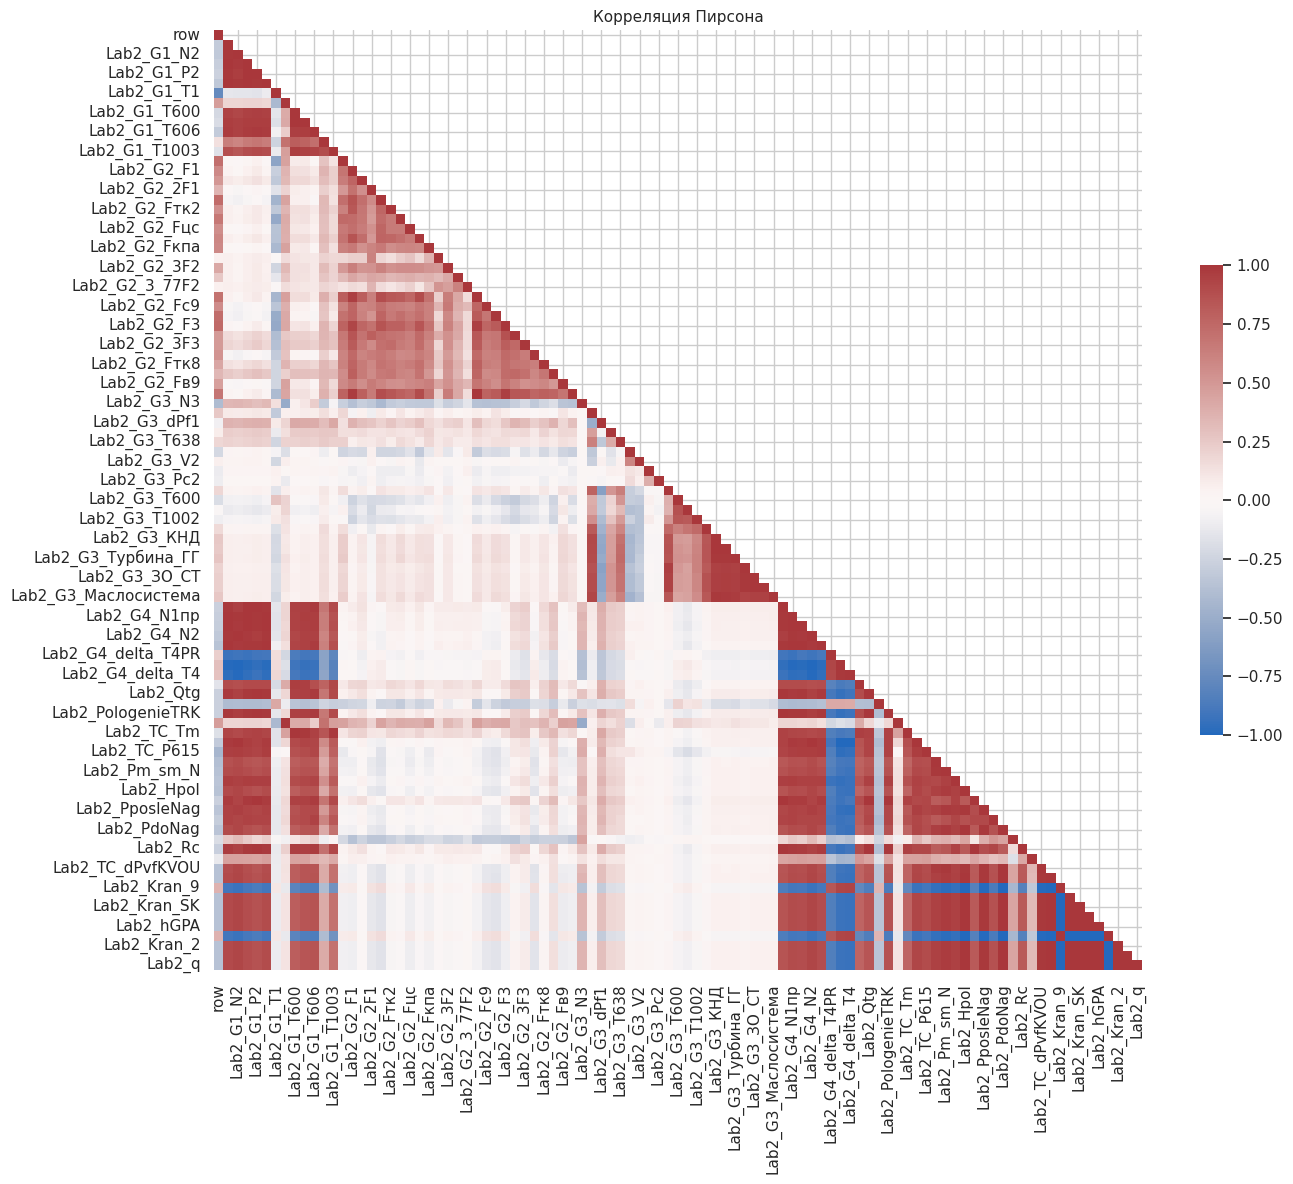

In [11]:
_var = df.var(numeric_only=True)
corr_cols = _var[_var > 1e-12].index.tolist()
CORR = df[corr_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(CORR, dtype=bool), k=1)
sns.heatmap(
    CORR,
    mask=mask,
    cmap="vlag",
    center=0,
    linewidths=0,
    cbar_kws={"shrink": 0.5},
)
plt.title("Корреляция Пирсона")
plt.tight_layout()
plt.show()


def pick_low_cross_correlation(corr: pd.DataFrame, k: int = 5) -> list[str]:
    """Жадно: добавляем признак с минимальным max_{j in S} |corr(i,j)| к уже выбранным S."""
    cols = list(corr.columns)
    A = corr.abs().reindex(index=cols, columns=cols)
    m = A.to_numpy().copy()
    np.fill_diagonal(m, np.nan)
    mean_abs = np.nanmean(m, axis=1)
    first = cols[int(np.nanargmin(mean_abs))]
    selected = [first]
    pool = [c for c in cols if c != first]

    while len(selected) < k and pool:
        best_c, best_score = None, np.inf
        for c in pool:
            score = max(float(A.loc[c, s]) for s in selected)
            if score < best_score:
                best_score, best_c = score, c
        selected.append(best_c)
        pool.remove(best_c)
    return selected


In [12]:
N_PLOT = min(10, len(corr_cols))
plot_cols = pick_low_cross_correlation(CORR, k=N_PLOT)
print("Колонки для графиков (слабо коррелируют между собой):", plot_cols)
try:
    from IPython.display import display as _d
    _d(CORR.loc[plot_cols, plot_cols].style.format("{:.2f}"))
except Exception:
    print(CORR.loc[plot_cols, plot_cols])

Колонки для графиков (слабо коррелируют между собой): ['Lab2_G3_Pc2', 'Lab2_TC_Ptgdg', 'Lab2_G2_Fтк4', 'Lab2_G3_V2', 'Lab2_G3_Pm', 'Lab2_dev', 'Lab2_G3_dPf1', 'Lab2_TdoNag', 'Lab2_G1_T607', 'Lab2_G3_T600']


,Lab2_G3_Pc2,Lab2_TC_Ptgdg,Lab2_G2_Fтк4,Lab2_G3_V2,Lab2_G3_Pm,Lab2_dev,Lab2_G3_dPf1,Lab2_TdoNag,Lab2_G1_T607,Lab2_G3_T600
Lab2_G3_Pc2,1.00,0.00,-0.03,0.07,0.01,0.02,-0.05,-0.04,-0.11,-0.04
Lab2_TC_Ptgdg,0.00,1.00,-0.04,-0.05,-0.16,-0.17,-0.16,-0.24,-0.11,0.21
Lab2_G2_Fтк4,-0.03,-0.04,1.00,0.01,0.13,0.05,0.22,-0.23,0.27,-0.05
Lab2_G3_V2,0.07,-0.05,0.01,1.00,-0.12,0.02,0.06,-0.07,0.07,-0.31
Lab2_G3_Pm,0.01,-0.16,0.13,-0.12,1.00,0.10,-0.06,-0.03,0.15,0.20
Lab2_dev,0.02,-0.17,0.05,0.02,0.10,1.00,0.15,-0.18,0.12,-0.06
Lab2_G3_dPf1,-0.05,-0.16,0.22,0.06,-0.06,0.15,1.00,0.01,0.19,-0.32
Lab2_TdoNag,-0.04,-0.24,-0.23,-0.07,-0.03,-0.18,0.01,1.00,-0.08,0.02
Lab2_G1_T607,-0.11,-0.11,0.27,0.07,0.15,0.12,0.19,-0.08,1.00,0.20
Lab2_G3_T600,-0.04,0.21,-0.05,-0.31,0.20,-0.06,-0.32,0.02,0.20,1.00


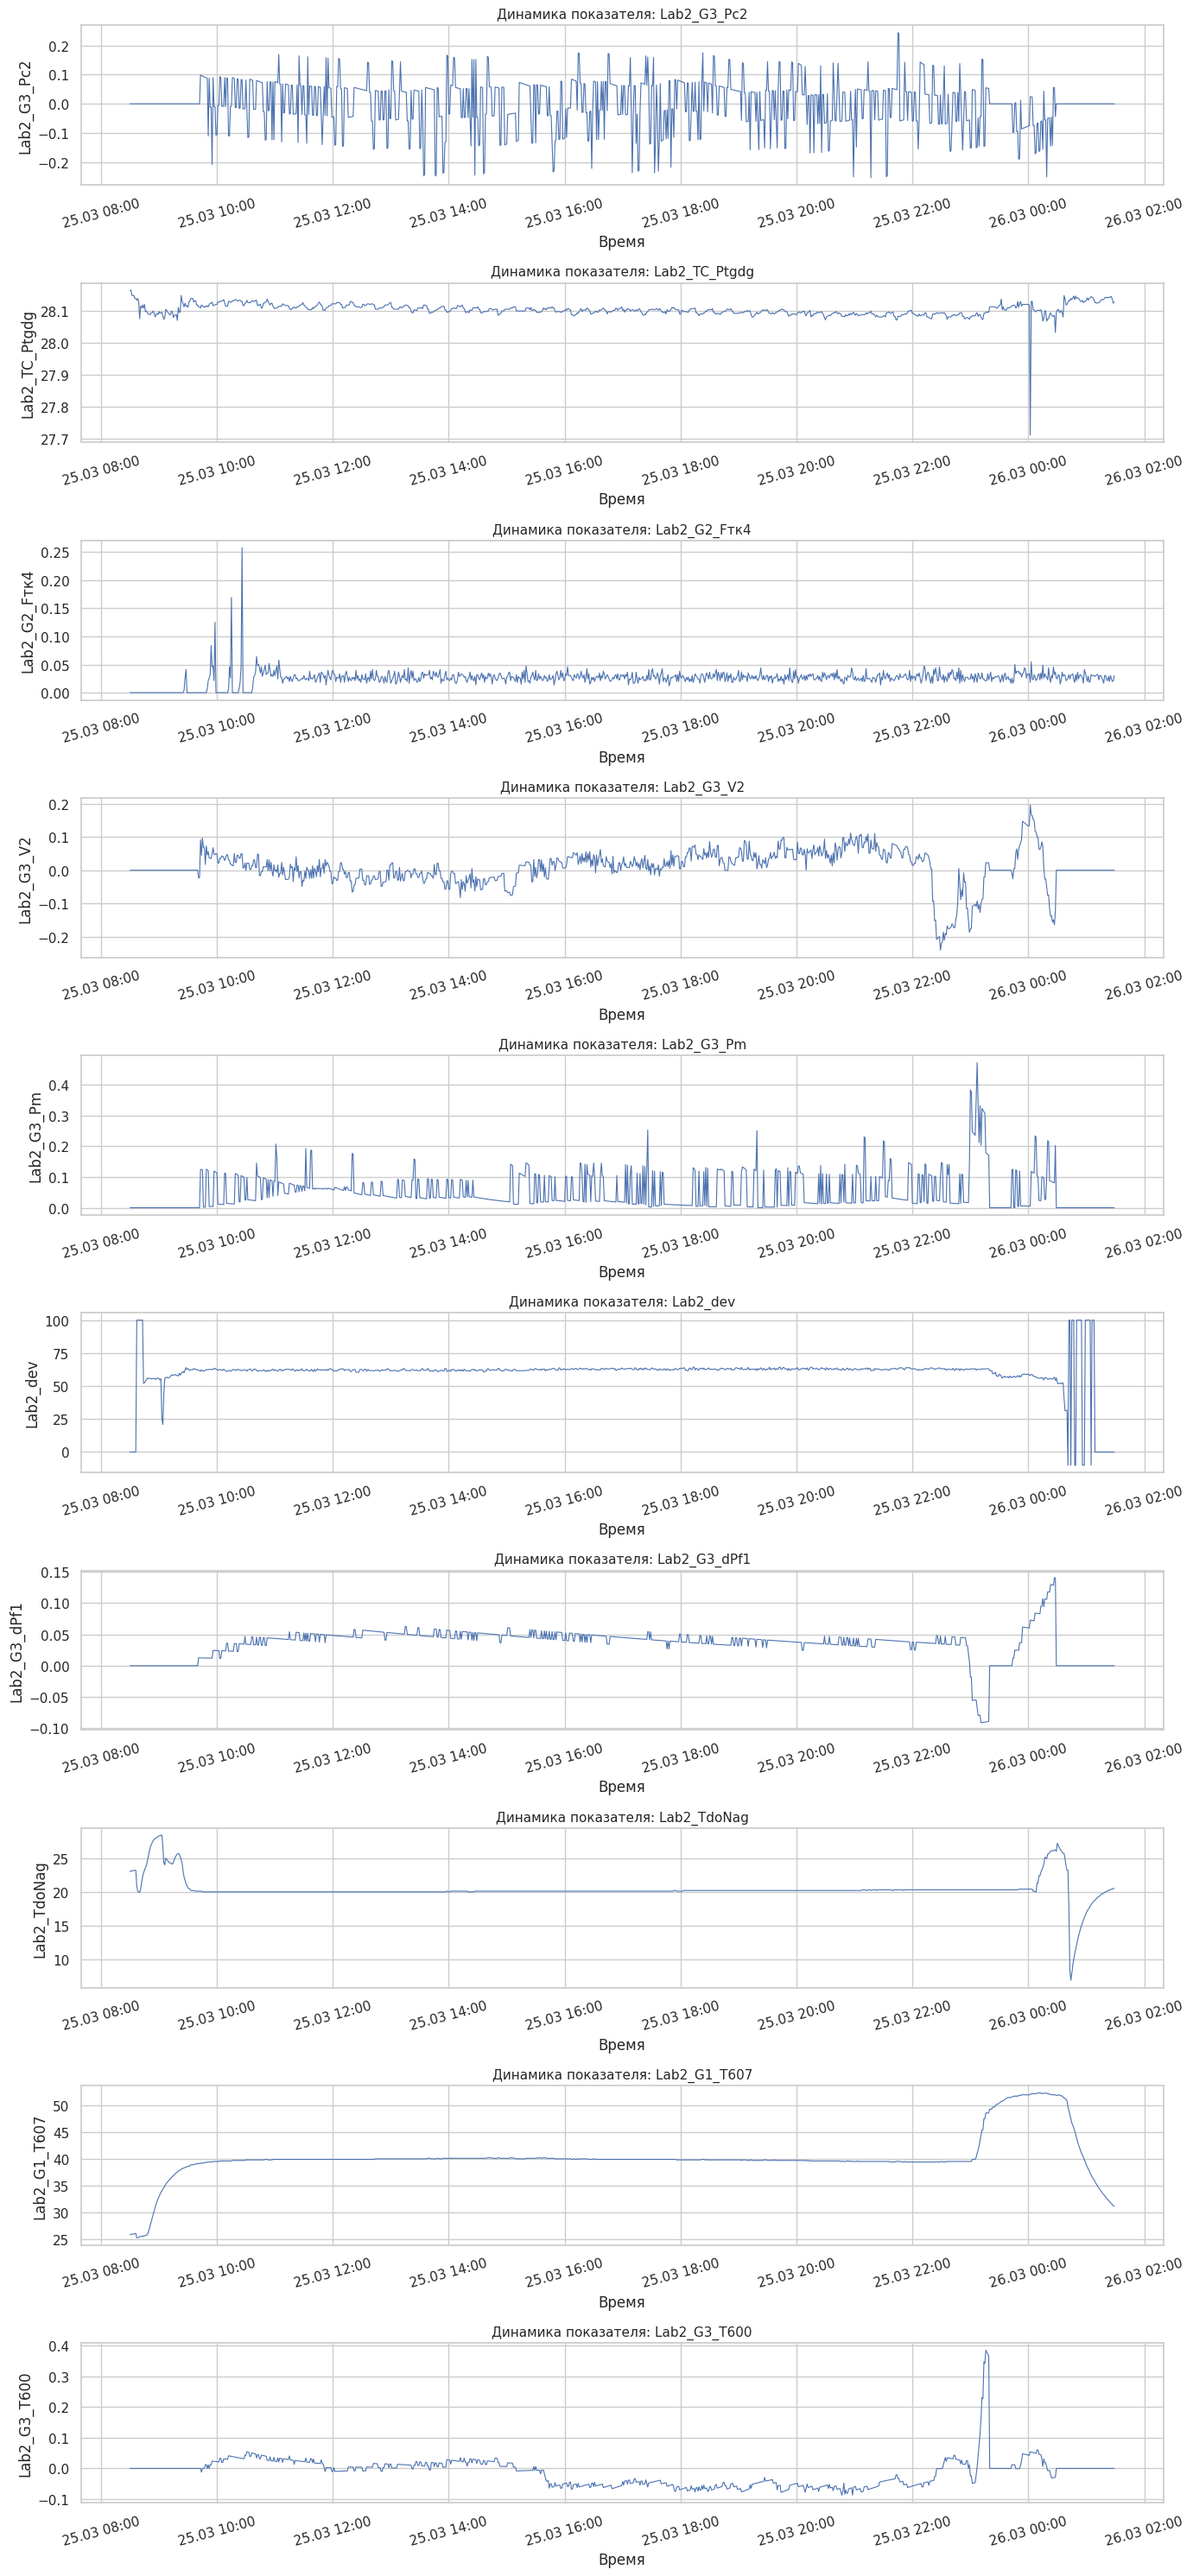

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 3.0 * len(plot_cols)))

if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    ax.plot(df.index, df[col], lw=0.8, color="C0")
    ax.set_ylabel(col)
    ax.set_title(f"Динамика показателя: {col}")
    ax.set_xlabel("Время")

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))

    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Lab2_G3_Pc2**: Четко выделяется период покоя (сигнал строго равен 0.0 в начале до ~09:50 и в конце после 00:30) и период высокой активности (с 09:50 до 00:10). Сигнал высокочастотный, знакопеременный, центрированный вокруг 0.0. Основные колебания зажаты в коридоре от -0.25 до +0.15. Около 21:50 зафиксирован одиночный максимальный выброс, пробивающий отметку +0.2. Общий тренд отсутствует, среднее значение на активном участке визуально остается стабильно близким к нулю.

**Lab2_TC_Ptgdg**: Около 00:00 происходит резкий, мгновенный провал до отметки 27.7. Сразу после этого сигнал возвращается к норме и даже совершает небольшой скачок вверх до ~28.15. Это похоже на кратковременный сбой датчика. В отличие от предыдущего показателя, этот сигнал ведет себя очень устойчиво на протяжении почти всего времени, удерживаясь в крайне узком диапазоне от 28.05 до 28.15.

**Lab2_G2_Fтк4**: График делится на две фазы - бурное начало (запуск/настройка) и последующий стабильный режим. В интервале с 09:00 до 10:50 наблюдается серия мощных единичных всплесков. Самый высокий из них пробивает отметку 0.25 (около 10:40). Это похоже на калибровку датчика или инициализацию системы. После 10:50 показатель успокаивается и переходит в стационарный режим.

**Lab2_G3_V2**: Сложный процесс с периодами абсолютного покоя (на нуле) в начале дня до 09:40 и после полуночи. В основной рабочий период с 09:40 до 21:50 сигнал ведет себя волнообразно: начальный скачок до +0.1 сменяется дневным проседанием в отрицательную зону до -0.08, которое затем переходит в затяжной подъем до +0.1. Финал работы (с 21:50 до 00:30) характеризуется нестабильностью: сначала происходит глубокий провал до абсолютного минимума -0.23, а после короткого затишья следует мощный компенсационный взлет до пика +0.2, который резко обрывается обратно в минус и уходит в ноль.

**Lab2_G3_Pm**: В начале дня (до 09:40) и в самом конце (после 00:30) система выключена (стоит на 0.0). С 09:40 начинается рабочий режим, который носит скачкообразный характер: показатель принимает значения в диапазоне от нуля и до +0.1. На протяжении всего дня (с 10:00 до 22:30) на этом фоне изредка возникают одиночные пики средней интенсивности, доходящие до 0.2 – 0.25. В интервале от 11:30 до 15:00 частота пульсаций падает, и сигнал образует плавно затухающие спады обратно к нулю. Главной особенностью графика является всплеск активности в районе 23:00. В этот период система испытывает максимальную нагрузку за сутки, а амплитуда сигнала резко удваивается, достигая абсолютного максимума графика на отметке 0.47. После этого экстремального пика интенсивность импульсов быстро снижается, и к началу следующих суток показатель полностью стабилизируется в нуле.

**Lab2_dev**: В моменты запуска (около 08:30) и перед завершением процесса (в районе 00:40) происходят резкие полноамплитудные скачки, полностью перекрывающие диапазон от 0 до 100. В финале это выглядит как серия прямоугольных высокоамплитудных импульсов. На старте (около 09:10) зафиксирован глубокий точечный провал сигнала вниз до отметки 25, а перед финальным отключением (с 23:30 до 00:30) наблюдается ступенчатое, контролируемое снижение уровня с 65 до 30. Почти 14 часов (с 9:30 до 23:30) процесс удерживается в жестко фиксированном коридоре около 65. Сигнал в этой фазе имеет плоский вид с минимальным шумом.

**Lab2_G3_dPf1**: После ступенчатого запуска процесс выходит на плавную дугу. Сигнал медленно растет до полудня (пик около 0.05), а затем на протяжении 10 часов совершает монотонное падение к отметке 0.03. Перед выключением показатель резко падает в отрицательную зону, достигая дна на отметке -0.09. Затем, после короткой фиксации на нуле, следует стремительный линейный взлет до абсолютного максимума 0.14.

**Lab2_TdoNag**: Основную часть суток (с 09:30 до 00:00) процесс статичен. Сигнал замирает на идеально ровной линии ровно на отметке 20. После 00:00 показатель плавно взлетает до пика 27, а затем мгновенно обрушивается до абсолютного минимума 7. Из этой нижней точки сигнал начинает плавное экспоненциальное восстановление обратно к базовым 20 единицам.

**Lab2_G1_T607**: Основное плато удерживается почти весь день (с 10:00 до 23:00) на отметке 40. Второе, повышенное плато формируется ближе к полуночи (23:00–00:00) на уровне 52.Изменения состояний происходят плавно, без рывков и шума, что  характерно для тепловых процессов (например, нагрева и остывания). На протяжении всего дня на сигнале практически отсутствуют пульсации, зазубрины или случайные выбросы - процесс протекает крайне стабильно и инерционно.

**Lab2_G3_T600**: Сигнал совершает плавные колебания вокруг нуля на протяжении дня. В первой половине (10:00–15:00) он держится в зоне до +0.05, а во второй половине (15:00–21:30) уходит в область до -0.08. Главное событие происходит около 23:00, когда показатель мгновенно взлетает до абсолютного максимума 0.39. Этот импульс имеет очень крутой подъем и такой же резкий сброс обратно к нулю.

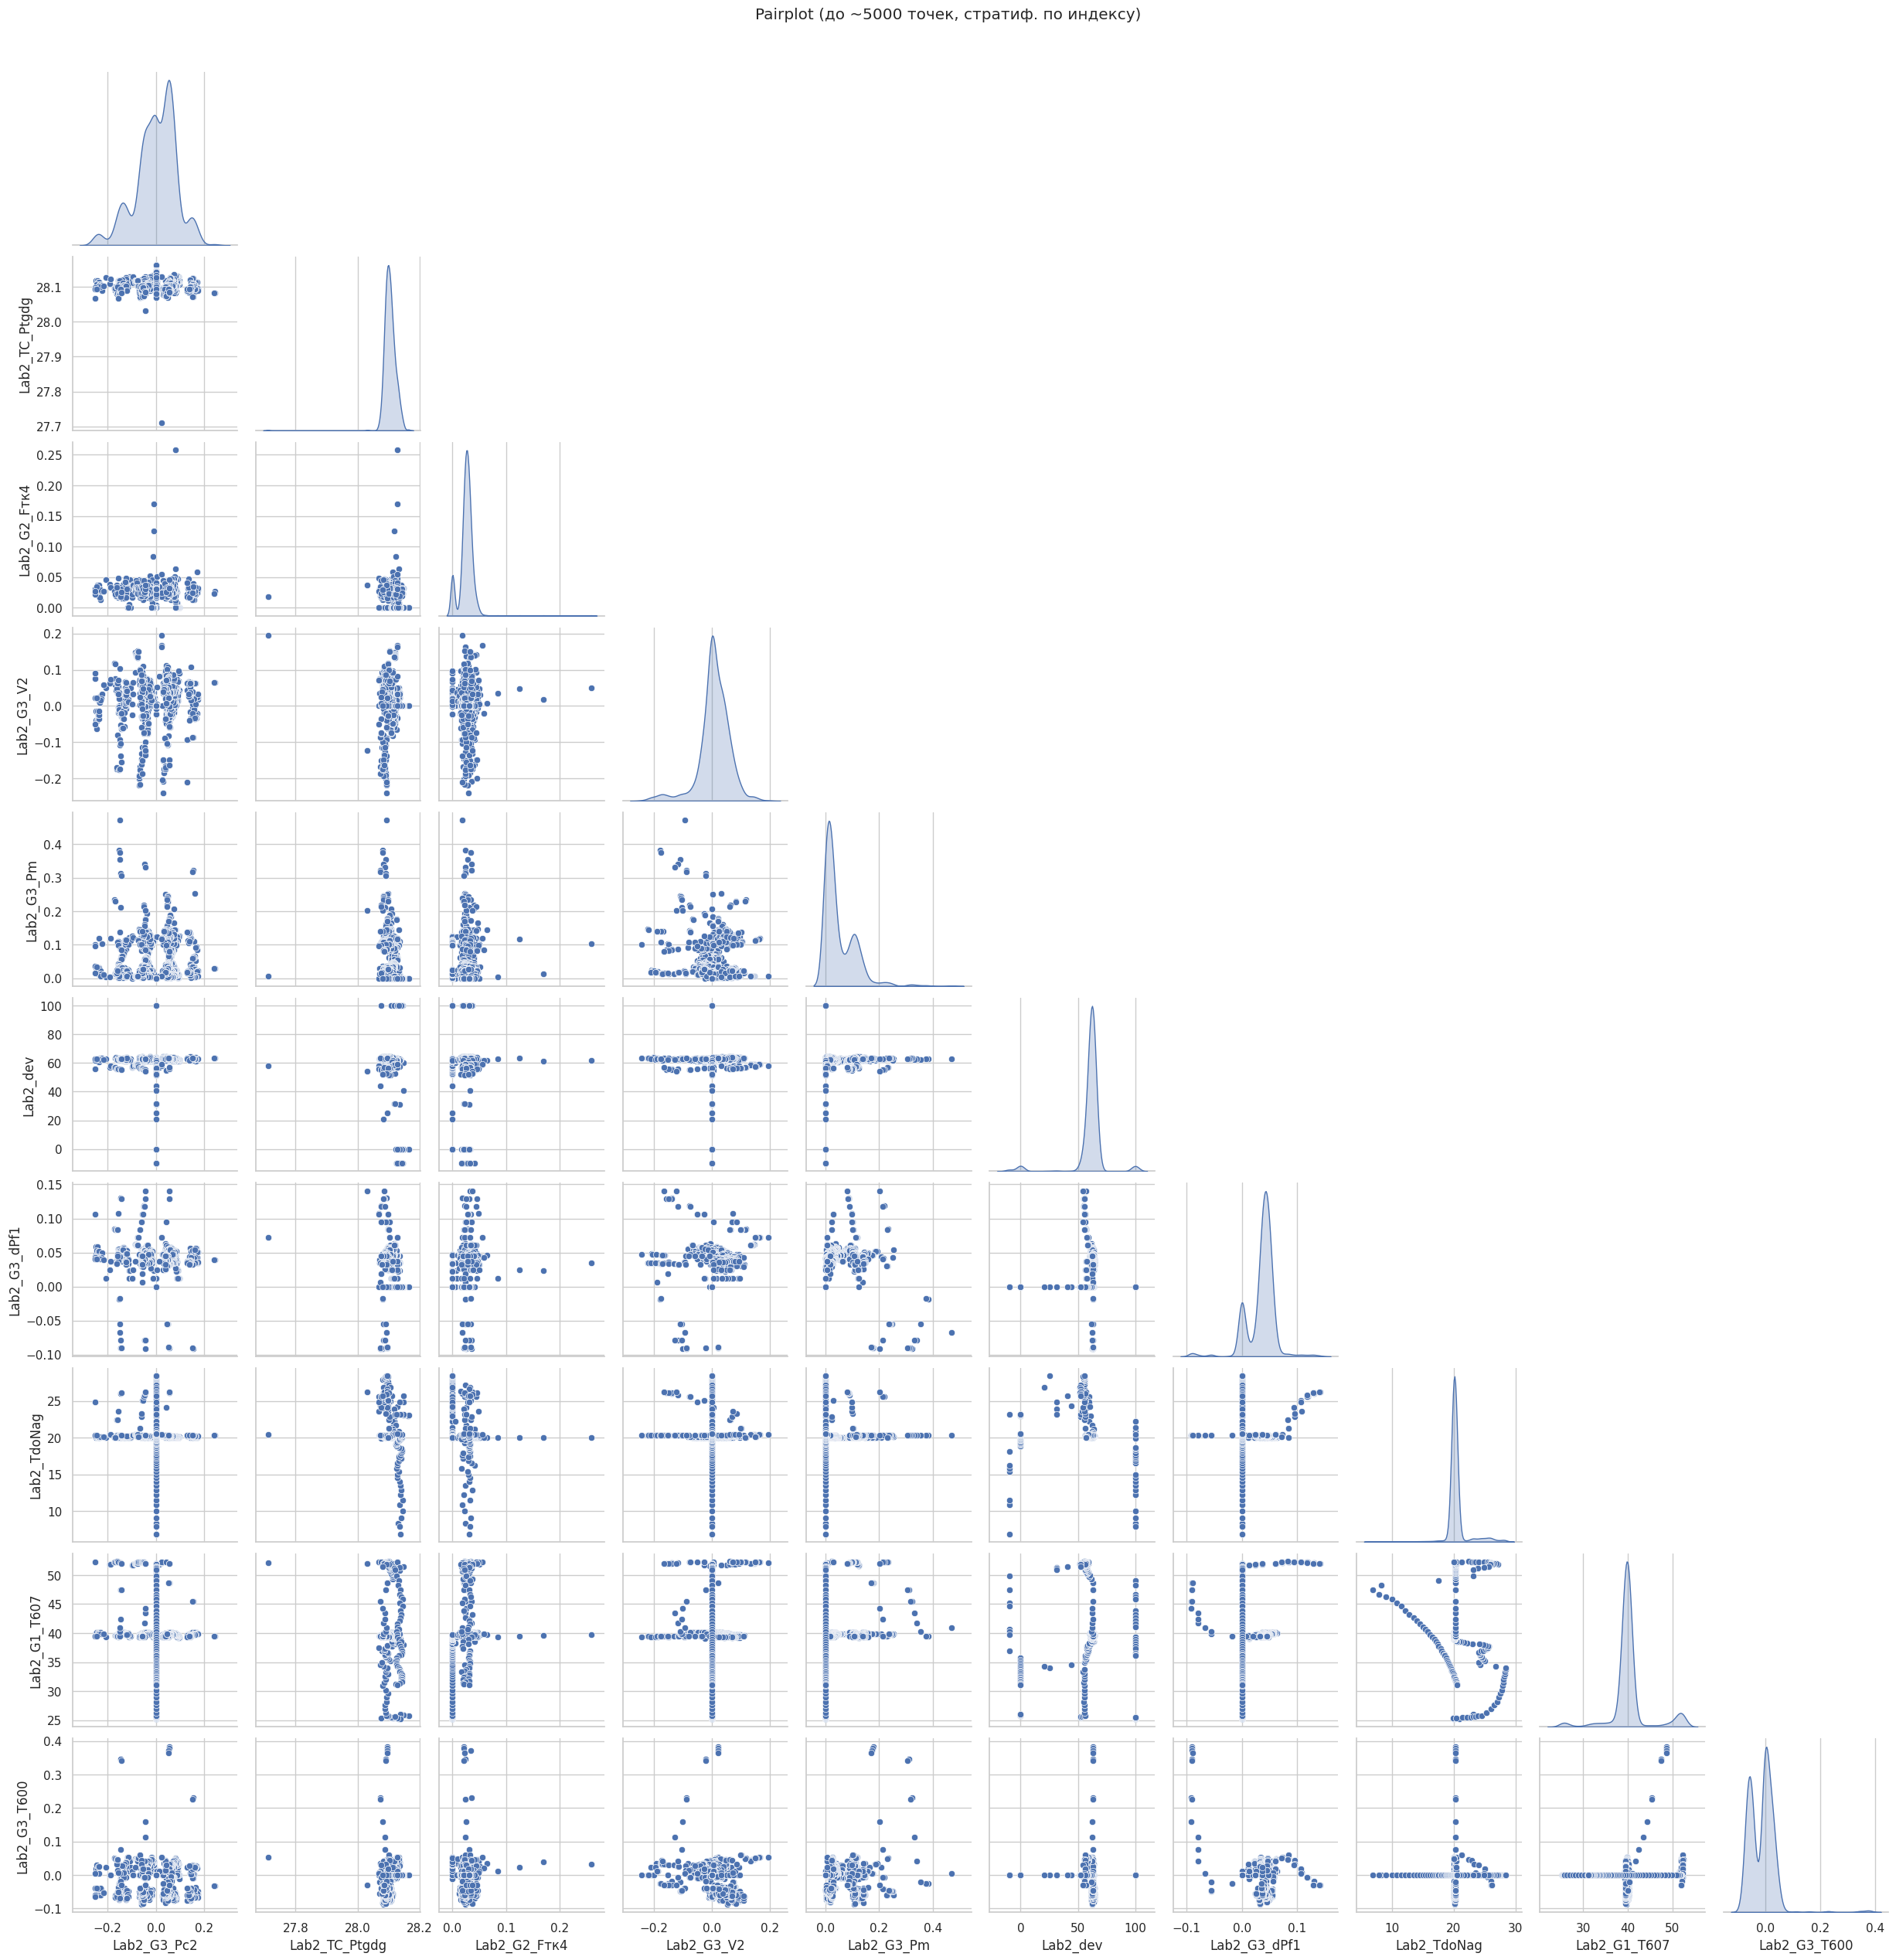

In [14]:
subset = df[plot_cols].dropna()
if subset.shape[1] >= 2:
    g = sns.pairplot(subset.iloc[:: max(1, len(subset) // 5000)], diag_kind="kde", corner=True)
    g.fig.suptitle("Pairplot (до ~5000 точек, стратиф. по индексу)", y=1.02)
    plt.show()

**Горизонтальные или вертикальные линии** означают, что одна переменная жестко зафиксирована на определенном уровне, в то время как вторая переменная в этот же момент активно меняется. В технических системах это признак дискретных режимов работы или периодов покоя (например, когда один датчик показывает ноль в режиме ожидания, а второй продолжает фиксировать флуктуации фона).

Пример пары: `Lab2_G1_T607` (ось Y) и `Lab2_G3_Pc2` (ось X). Можно заметить четкий «крест» из двух пересекающихся линий. Вертикальная линия на отметке $X = 0.0$ показывает, что пока импульсный параметр Pc2 спал в нуль, температура T607 успела побывать и на уровне 40, и на уровне 52. Две горизонтальные полосы показывают, что в рабочем режиме колебания Pc2 происходили строго при этих двух температурных режимах.

**Четкая наклонная диагональ** указывает на прямую линейную зависимость между процессами. Если линия идет снизу вверх — зависимость положительная (с ростом $X$ растет $Y$), если сверху вниз — отрицательная. Это говорит о том, что процессы жестко связаны физически или один параметр напрямую управляет вторым.

Пример пары: `Lab2_G1_T607` (ось X) и `Lab2_G3_T600` (ось Y) — правый нижний угол матрицы. Здесь видна прямая физическая связь двух температурных датчиков: когда растет температура T607 (с 40 до 52), пропорционально и линейно увеличиваются показания T600 (с 0.0 до 0.38).

**Гладкие дуги, петли, окружности и сложные кривые** отражают нелинейную, но строгую взаимосвязь. Это фазовый портрет переходного процесса. Такие траектории возникают из-за тепловой инерции, запаздывания датчиков или алгоритмов разгона/торможения: точки последовательно «перетекают» из одного состояния в другое, прорисовывая геометрию физического закона.

Пример пары: `Lab2_G1_T607` (ось Y) и `Lab2_TdoNag` (ось X). Гладкая дуга-петля в левой части графика, похожая на закругление цифры «5». Это фазовый портрет аварийного или финального отключения. Параметры меняются не мгновенно: пока один показатель стремительно падал вниз (срыв давления/потока в TdoNag до 7), температурный датчик T607 из-за физической инерции остывал плавно, прорисовав дугу.

**Плотное бесформенное облако точек** (круг или овал) свидетельствует об отсутствии взаимосвязи между переменными в этой зоне. Как правило, этот паттерн образуется в штатном режиме работы вокруг нулевых или базовых значений, показывая, что параметры просто независимо «шумят» (совершают мелкие случайные колебания) и не влияют друг на друга.

Пример пары: `Lab2_G3_Pm` (ось Y) и `Lab2_G3_V2` (ось X). Бесформенное, горизонтально вытянутое облако точек в районе нуля. В штатном режиме работы эти два параметра никак не связаны между собой. Датчики просто одновременно фиксируют случайные мелкие колебания рабочей среды, образуя хаотичную «тучку» данных.

**Изолированные редкие точки**, оторванные от общей массы подсвечивают кратковременные аномалии, выбросы или пусковые/финальные скачки. Система находится в этих критических состояниях считанные секунды, поэтому на графике не успевает накопиться массив данных, и переходные пики выглядят как одинокие точки-одиночки вдали от основных кластеров.

Пример пары: `Lab2_G2_Fтк4` (ось Y) и практически любая переменная (например, `Lab2_G3_Pc2` по оси X). Основная масса точек лежит на горизонтальной линии около нуля, но вверх (до значений 0.10–0.25) улетают единичные, оторванные от коллектива точки. Это самые пусковые пики-выбросы, которые можно наблюдать на временном графике Fтк4 между 09:00 и 10:30. Так как эти всплески были мгновенными, система сделала всего пару замеров в этих координатах.

#### Фильтрация признаков и выбор целевого временного ряда


Необходимо выбрать один или несколько наиболее информативных непрерывных временных рядов. Для этого проведем автоматизированную очистку признакового пространства:

**Удаление неинформативных признаков:**
Рассчитаем дисперсию для всех переменных и исключим константные колонки (где дисперсия $\approx 0$). Они не содержат динамики и бесполезны для поиска скрытых режимов.

**Изоляция бинарных (статусных) сигналов:**
Признаки, принимающие не более двух уникальных значений, отсортируем в отдельный датафрейм `regime_signals`. Это дискретные статусы оборудования (например, вкл/выкл). Мы исключаем их из непрерывного TDA-анализа, но сохраняем для этапа интерпретации: они понадобятся для валидации скрытых режимов, которые найдет топологический алгоритм.

In [15]:
_var_all = df.var(numeric_only=True)
const_cols = _var_all[_var_all <= 1e-12].index.tolist()

_num = df.select_dtypes(include=[np.number]).drop(columns=const_cols, errors="ignore")
_nun = _num.nunique(dropna=True)
binary_cols = _nun[_nun <= 2].index.tolist()
continuous_cols = [c for c in _num.columns if c not in binary_cols]

regime_signals = df[binary_cols].copy()
df_cont = df[continuous_cols].copy()

print(f"Константных колонок отброшено: {len(const_cols)}")
print(f"Бинарных сигналов (regime_signals): {len(binary_cols)}")
print(f"Непрерывных кандидатов: {len(continuous_cols)}")
print("Бинарные сигналы (для валидации кластеров):")
print(binary_cols)

Константных колонок отброшено: 21
Бинарных сигналов (regime_signals): 11
Непрерывных кандидатов: 86
Бинарные сигналы (для валидации кластеров):
['Lab2_TC_dPvfKVOU', 'Lab2_Kran_12', 'Lab2_Kran_9', 'Lab2_U_Kran_GPA_A_OGK', 'Lab2_Kran_SK', 'Lab2_Kp', 'Lab2_hGPA', 'Lab2_Kran_5', 'Lab2_Kran_2', 'Lab2_Kran_1', 'Lab2_q']


In [16]:
target_scores = CORR.abs().sum(axis=1).sort_values(ascending=False)

print("Рейтинг кандидатов на целевую переменную (по убыванию системной связи):")
print("-" * 60)
for i, (col, score) in enumerate(target_scores.items(), 1):
    # вычитаем 1, чтобы не учитывать корреляцию признака сам с собой (которая всегда = 1)
    net_score = score - 1
    mean_r = net_score / (len(CORR) - 1)
    print(f"{i:<2} | {col:<15} | Сумма |R|: {net_score:.2f} | Средний |R|: {mean_r:.3f}")

Рейтинг кандидатов на целевую переменную (по убыванию системной связи):
------------------------------------------------------------
1  | Lab2_G1_T638    | Сумма |R|: 46.34 | Средний |R|: 0.483
2  | Lab2_PologenieTRK | Сумма |R|: 45.98 | Средний |R|: 0.479
3  | Lab2_G4_N1пр    | Сумма |R|: 45.97 | Средний |R|: 0.479
4  | Lab2_G1_N1      | Сумма |R|: 45.88 | Средний |R|: 0.478
5  | Lab2_G1_P2      | Сумма |R|: 45.84 | Средний |R|: 0.477
6  | Lab2_G1_N3      | Сумма |R|: 45.81 | Средний |R|: 0.477
7  | Lab2_G4_T4пр    | Сумма |R|: 45.72 | Средний |R|: 0.476
8  | Lab2_G4_Р2пр    | Сумма |R|: 45.71 | Средний |R|: 0.476
9  | Lab2_Qtg        | Сумма |R|: 45.67 | Средний |R|: 0.476
10 | Lab2_G1_T4ср    | Сумма |R|: 45.63 | Средний |R|: 0.475
11 | Lab2_G1_N2      | Сумма |R|: 45.58 | Средний |R|: 0.475
12 | Lab2_G4_N2      | Сумма |R|: 45.58 | Средний |R|: 0.475
13 | Lab2_G4_delta_P2PR | Сумма |R|: 45.33 | Средний |R|: 0.472
14 | Lab2_PposleNag  | Сумма |R|: 45.25 | Средний |R|: 0.471
15 | Lab

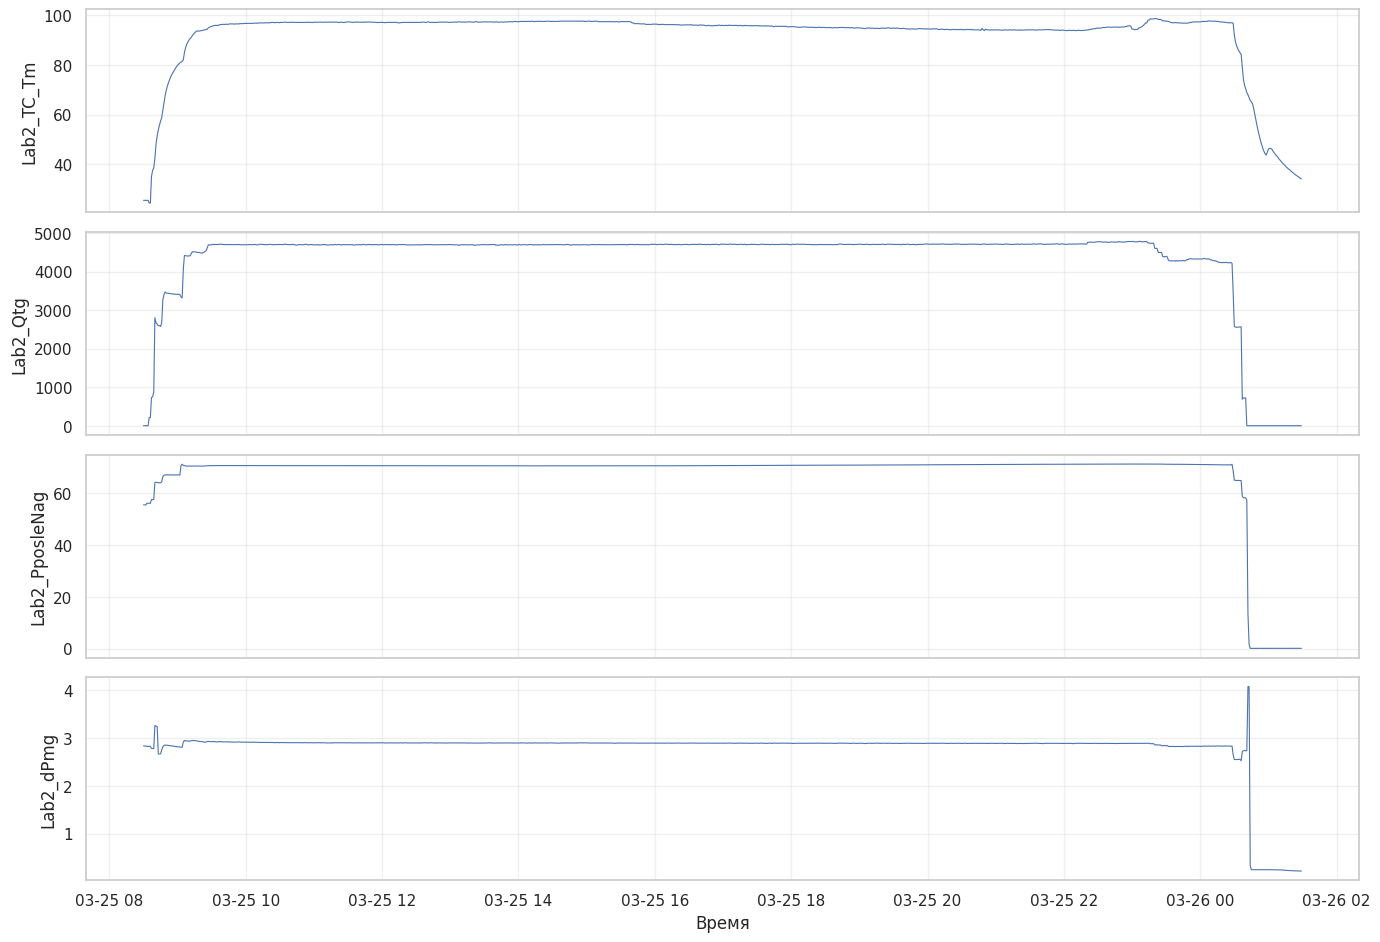

                   min    median       max       std     cv  share_zero
Lab2_TC_Tm      24.400    95.900    98.600    13.417  0.146       0.000
Lab2_Qtg         0.000  4701.000  4786.000  1135.807  0.262       0.053
Lab2_PposleNag   0.060    70.740    71.360    14.981  0.223       0.000
Lab2_dPmg        0.214     2.893     4.079     0.555  0.200       0.000


In [17]:
CANDIDATES = ["Lab2_TC_Tm", "Lab2_Qtg", "Lab2_PposleNag", "Lab2_dPmg"]
CANDIDATES = [c for c in CANDIDATES if c in df_cont.columns]

fig, axes = plt.subplots(len(CANDIDATES), 1, figsize=(14, 2.4 * len(CANDIDATES)), sharex=True)
for ax, col in zip(axes, CANDIDATES):
    ax.plot(df_cont.index, df_cont[col], lw=0.8)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Время")
plt.tight_layout()
plt.show()

stats = pd.DataFrame({
    "min": df_cont[CANDIDATES].min(),
    "median": df_cont[CANDIDATES].median(),
    "max": df_cont[CANDIDATES].max(),
    "std": df_cont[CANDIDATES].std(),
    "cv": df_cont[CANDIDATES].std() / (df_cont[CANDIDATES].abs().mean() + 1e-9),
    "share_zero": (df_cont[CANDIDATES] == 0).mean(),
})
print(stats.round(3))

**Выбор целевого признака:**
На основе сводной статистики (доля нулевых значений, коэффициент вариации) из пула непрерывных кандидатов в качестве основного целевого ряда выбран **`Lab2_TC_Tm`**.
Как видно из построенного графика и статистик, этот ряд обладает достаточной волатильностью, имеет непрерывную физическую природу и содержит визуально различимые паттерны динамики, что делает его оптимальным кандидатом.

Целевой ряд: Lab2_TC_Tm
Длина: 1020 точек, шаг ~1 мин, период 2022-03-25 08:29:59.999999+00:00 → 2022-03-26 01:28:59.999999+00:00
min=24.400, median=95.900, max=98.600, std=13.417


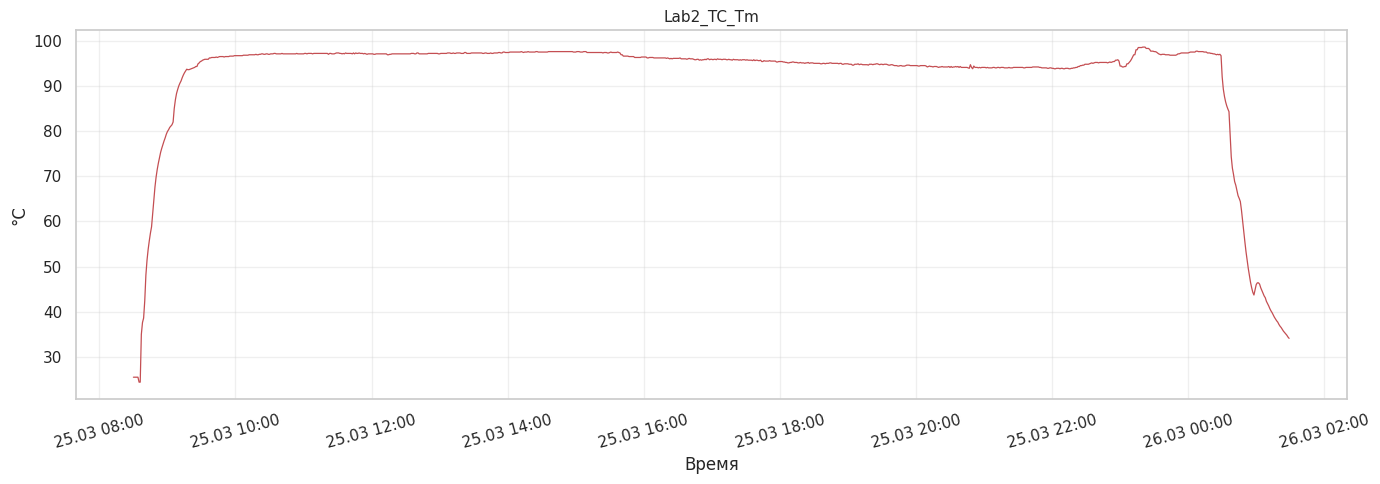

In [18]:
TARGET_COL = "Lab2_TC_Tm"
y = df_cont[TARGET_COL].astype(float).copy()
y.name = TARGET_COL

print(f"Целевой ряд: {TARGET_COL}")
print(f"Длина: {len(y)} точек, шаг ~1 мин, период {y.index.min()} → {y.index.max()}")
print(f"min={y.min():.3f}, median={y.median():.3f}, max={y.max():.3f}, std={y.std():.3f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y.index, y.values, lw=0.9, color="C3")
ax.set_title(f"Lab2_TC_Tm")
ax.set_xlabel("Время")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))
ax.tick_params(axis='x', rotation=15)
ax.set_ylabel("°C")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Определение природы порождающего процесса

#### Показатель Хёрста (R/S-анализ).

Для оценки персистентности (склонности к трендовости) ряда мы используем классический **R/S-анализ**. В качестве дополнительной проверки применяется метод **DFA (Detrended Fluctuation Analysis)**, который более устойчив к локальным трендам и шумам в реальных промышленных данных.
* $H \approx 0.5$ — случайное блуждание.
* $H < 0.5$ — антиперсистентный ряд (возврат к среднему).
* $H > 0.5$ — персистентный ряд (долгая память, трендовость).

In [19]:
pip install nolds

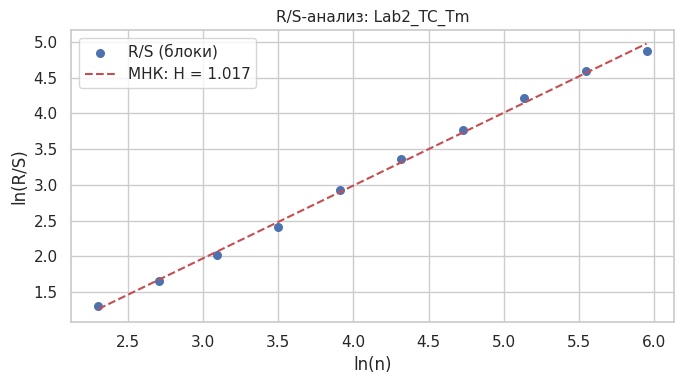

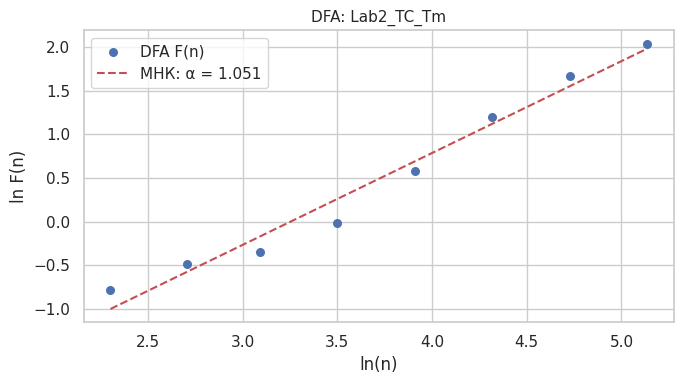

Показатель Хёрста (R/S) : H = 1.0173
Показатель Хёрста (DFA) : H = 1.0515

Интерпретация: персистентный процесс (долгая положительная память)


In [20]:
import nolds
from nolds.measures import logarithmic_n
import numpy as np

y_arr = y.values.astype(float)

def hurst_rs_plot(x, nvals=None, title="R/S-анализ"):
    N = len(x)
    if nvals is None:
        nvals = logarithmic_n(10, N // 2, 1.5)
    nvals = np.array([n for n in nvals if n >= 8])

    rs_vals = []
    for n in nvals:
        blocks = [x[i:i+n] for i in range(0, N - n + 1, n)]
        rs_block = []
        for b in blocks:
            b = np.asarray(b, dtype=float)
            mean = b.mean()
            dev = np.cumsum(b - mean)
            R = dev.max() - dev.min()
            S = b.std(ddof=1)
            if S > 0:
                rs_block.append(R / S)
        if rs_block:
            rs_vals.append(np.mean(rs_block))

    nvals_ok = nvals[:len(rs_vals)]
    log_n = np.log(nvals_ok)
    log_rs = np.log(rs_vals)
    H_est, intercept = np.polyfit(log_n, log_rs, 1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(log_n, log_rs, s=30, label="R/S (блоки)")
    x_line = np.linspace(log_n.min(), log_n.max(), 100)
    ax.plot(x_line, H_est * x_line + intercept, "r--", label=f"МНК: H = {H_est:.3f}")
    ax.set_xlabel("ln(n)")
    ax.set_ylabel("ln(R/S)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return H_est

def dfa_plot(x, nvals=None, order=1, title="DFA"):
    N = len(x)
    if nvals is None:
        nvals = logarithmic_n(10, N // 4, 1.5)
    nvals = np.array([n for n in nvals if n >= 8])

    flucts = []
    for n in nvals:
        blocks = [x[i:i+n] for i in range(0, N - n + 1, n)]
        f_sq = []
        for b in blocks:
            b = np.asarray(b, dtype=float)
            t = np.arange(len(b))
            coeffs = np.polyfit(t, b, order)
            trend = np.polyval(coeffs, t)
            f_sq.append(np.mean((b - trend) ** 2))
        flucts.append(np.sqrt(np.mean(f_sq)))

    log_n = np.log(nvals)
    log_f = np.log(flucts)
    alpha, intercept = np.polyfit(log_n, log_f, 1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(log_n, log_f, s=30, label="DFA F(n)")
    x_line = np.linspace(log_n.min(), log_n.max(), 100)
    ax.plot(x_line, alpha * x_line + intercept, "r--", label=f"МНК: α = {alpha:.3f}")
    ax.set_xlabel("ln(n)")
    ax.set_ylabel("ln F(n)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return alpha

H_rs_plot = hurst_rs_plot(y_arr, title=f"R/S-анализ: {TARGET_COL}")
alpha_dfa = dfa_plot(y_arr, title=f"DFA: {TARGET_COL}")

print(f"Показатель Хёрста (R/S) : H = {H_rs_plot:.4f}")
print(f"Показатель Хёрста (DFA) : H = {alpha_dfa:.4f}")

if H_rs_plot > 0.5:
    interp = "персистентный процесс (долгая положительная память)"
elif H_rs_plot < 0.5:
    interp = "антиперсистентный процесс (возвраты к среднему)"
else:
    interp = "близок к случайному блужданию (кратковременная память)"
print(f"\nИнтерпретация: {interp}")

#### Оценка старшего показателя Ляпунова
Максимальный показатель Ляпунова ($\lambda_1$) характеризует скорость экспоненциального расхождения бесконечно близких траекторий в фазовом пространстве. Положительное значение ($\lambda_1 > 0$) является строгим индикатором наличия детерминированного хаоса.

Для расчета по алгоритму Розенштейна нам предварительно требуются параметры вложения (временная задержка $\tau$ и размерность $m$).
* Задержку $\tau$ найдем надежным методом — как первый ноль автокорреляционной функции (ACF).
* Размерность $m$ для *черновой* оценки примем равной 3 (точный подбор размерности будет проведен в Пункте 3 методом Брумхеда-Кинга).

Первый ноль ACF: lag (tau) = 56


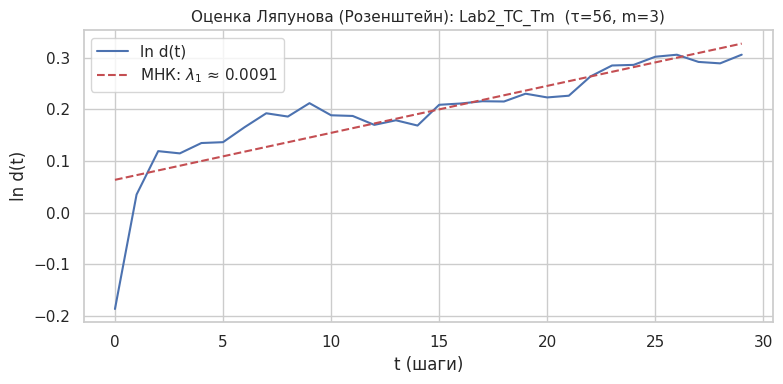

Старший показатель Ляпунова: λ1 ≈ 0.00909


In [21]:
from statsmodels.tsa.stattools import acf as _acf
import warnings

# оптимальная задержка (первый ноль ACF) ---
def first_acf_zero(x, nlags=200):
    a = _acf(x, nlags=nlags, fft=True)
    for i in range(1, len(a)):
        if a[i] <= 0:
            return i
    return nlags

tau_acf = first_acf_zero(y_arr)
print(f"Первый ноль ACF: lag (tau) = {tau_acf}")

TAU_ROUGH = max(tau_acf, 1)
M_ROUGH   = 3

def lyap_plot(x, tau, emb_dim, traj_len=30, title="Алгоритм Розенштейна"):
    N = len(x)
    n_pts = N - (emb_dim - 1) * tau
    if n_pts <= 0:
        return

    X = np.stack([x[i * tau: i * tau + n_pts] for i in range(emb_dim)], axis=1)
    from sklearn.neighbors import BallTree
    tree = BallTree(X)
    min_tsep = tau

    log_d = np.full(traj_len, np.nan)
    counts = np.zeros(traj_len)

    for idx in range(len(X)):
        dists, inds = tree.query(X[idx:idx+1], k=2 + min_tsep * emb_dim)
        inds = inds[0]
        valid = [j for j in inds[1:] if abs(j - idx) > min_tsep]
        if not valid:
            continue
        nn = valid[0]
        for k in range(traj_len):
            i1, i2 = idx + k, nn + k
            if i1 >= len(X) or i2 >= len(X):
                break
            d = np.linalg.norm(X[i1] - X[i2])
            if d > 0:
                if np.isnan(log_d[k]):
                    log_d[k] = np.log(d)
                else:
                    log_d[k] += np.log(d)
                counts[k] += 1

    ok = counts > 0
    log_d[ok] /= counts[ok]

    t = np.arange(traj_len)
    ok_finite = ok & np.isfinite(log_d)
    slope, intercept = np.polyfit(t[ok_finite], log_d[ok_finite], 1)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(t[ok_finite], log_d[ok_finite], lw=1.5, label="ln d(t)")
    ax.plot(t[ok_finite], slope * t[ok_finite] + intercept, "r--", label=f"МНК: $\\lambda_{{1}}$ ≈ {slope:.4f}")
    ax.set_xlabel("t (шаги)")
    ax.set_ylabel("ln d(t)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return slope

lyap_slope = lyap_plot(
    y_arr, tau=TAU_ROUGH, emb_dim=M_ROUGH,
    traj_len=30,
    title=f"Оценка Ляпунова (Розенштейн): {TARGET_COL}  (τ={TAU_ROUGH}, m={M_ROUGH})"
)

print(f"Старший показатель Ляпунова: λ1 ≈ {lyap_slope:.5f}")

#### Обоснованный вывод о природе порождающих процессов

По итогам расчетов фрактальных и динамических характеристик целевого временного ряда получены следующие метрики:
- $H_{RS} \approx 1.017$, $H_{DFA} \approx 1.052$
- $\tau_{ACF} = 56$,
- $\lambda_1 \approx 0.00922$

1. Оба метода для расчета показателя Хёрста выдали значения чуть больше единицы. Вообще по теории этот коэффициент должен быть от 0 до 1, но на реальных данных цифры больше 1 просто означают, что наш график нестационарный и у него есть мощный постоянный тренд (то есть значения не скачут вокруг одной линии, а уверенно идут в одну сторону). У системы очень хорошая «память» - она долго копит изменения (температуру или нагар от кокса) в течение всего рабочего цикла, а обнуляется только в самом конце, когда установку выключают.

2. Автокорреляция показала значение 56. Это значит, что графику нужно 56 шагов по времени, чтобы его текущее состояние перестало напрямую зависеть от того, что было в самом начале. Для нас это знак, что процессы в оборудовании идут плавно, без резких хаотичных прыжков. Поэтому, когда мы будем дальше восстанавливать фазовое пространство, шаг нужно брать пошире, чтобы модель замечала реальные изменения, а не топталась на месте.

3. Старший показатель Ляпунова получился больше нуля, хоть и маленьким ($\lambda_1 \approx 0.00922$). Процесс подчиняется четким физическим законам, просто сама система довольно хаотическая. Так как цифра очень близка к нулю, траектории в системе расходятся медленно. Система ведет себя предсказуемо и стабильно на больших промежутках времени.

###  Вложение временного ряда

#### Равномерное вложение (Uniform Embedding)

В равномерном вложении векторы формируются с постоянным шагом задержки $\tau$.
Оптимальная задержка уже найдена в п.2 через автокорреляционную функцию: $\tau = 56$.

Для определения **оптимальной размерности вложения $m$** применим **метод Брумхеда-Кинга (Broomhead-King / SVD)**.
Суть метода:
1. Строится матрица траекторий с избыточно большим окном вложения.
2. К матрице применяется сингулярное разложение (SVD).
3. По графику сингулярных чисел (scree plot) мы ищем «излом» (elbow) — момент, где значимые компоненты системы заканчиваются и начинается шумовое плато. Количество значимых компонент и будет нашей размерностью $m$.

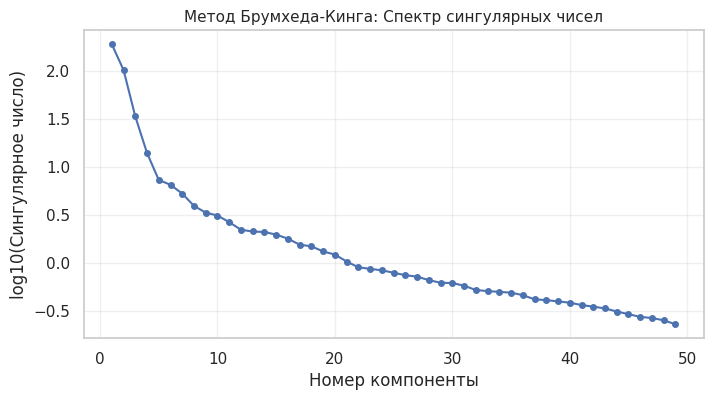

In [22]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# Метод Брумхеда-Кинга (SVD) для поиска размерности m
L_max = 50 # избыточное окно
N = len(y_arr)

# Матрица траекторий
X_trajectory = np.column_stack([y_arr[i : N - L_max + i + 1] for i in range(L_max)])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_trajectory)

# SVD
svd = TruncatedSVD(n_components=L_max - 1, random_state=42)
svd.fit(X_scaled)

# График сингулярных чисел
plt.figure(figsize=(8, 4))
plt.plot(range(1, L_max), np.log10(svd.singular_values_), marker='o', markersize=4, color='C0')
plt.title('Метод Брумхеда-Кинга: Спектр сингулярных чисел')
plt.xlabel('Номер компоненты')
plt.ylabel('log10(Сингулярное число)')
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
M_OPT = 5
TAU_OPT = int(tau_acf) # tau = 56

def uniform_embedding(x, tau, m):
    n_pts = len(x) - (m - 1) * tau
    return np.column_stack([x[i * tau : i * tau + n_pts] for i in range(m)])

X_uniform = uniform_embedding(y_arr, tau=TAU_OPT, m=M_OPT)
print(f"Размерность равномерного вложения: {X_uniform.shape}")

Размерность равномерного вложения: (796, 5)


#### Неравномерное вложение (Non-uniform Embedding)

В реальных физических системах процессы часто протекают на разных временных масштабах. Использование одной фиксированной задержки $\tau$ может скрыть часть динамики.
Мы применим **жадный алгоритм максимизации предсказательной способности (Predictive Skill)** на основе k-NN.

**Логика алгоритма:**
Мы итеративно добавляем новые значения задержек $\tau_i$, на каждом шаге выбирая ту задержку, добавление которой в фазовое пространство дает наименьшую среднеквадратичную ошибку (MSE) при предсказании следующего состояния системы $x(t+1)$ с помощью регрессора k-ближайших соседей. Процесс останавливается, когда добавление новых размерностей перестает значимо снижать ошибку прогноза.

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def greedy_non_uniform_embedding(x, max_dim=5, candidate_taus=range(1, 150, 5), sample_size=5000):
    """
    Жадный поиск оптимальных задержек.
    """
    N = len(x)
    selected_taus = [0] # 1 координата - само значение без задержки
    best_mses = []

    # Целевая переменная
    y_target = x[1:]

    for dim in range(1, max_dim):
        best_tau = None
        best_mse = float('inf')

        for tau in candidate_taus:
            if tau in selected_taus:
                continue

            current_taus = selected_taus + [tau]
            max_t = max(current_taus)

            # Матрица признаков для текущих tau
            n_pts = N - max_t - 1
            if n_pts < 100:
                continue

            X_temp = np.column_stack([x[max_t - t : max_t - t + n_pts] for t in current_taus])
            Y_temp = y_target[max_t : max_t + n_pts]

            if len(X_temp) > sample_size:
                idx = np.random.choice(len(X_temp), sample_size, replace=False)
                X_temp, Y_temp = X_temp[idx], Y_temp[idx]

            # k-NN
            X_train, X_test, y_train, y_test = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42)
            knn = KNeighborsRegressor(n_neighbors=5)
            knn.fit(X_train, y_train)
            preds = knn.predict(X_test)
            mse = mean_squared_error(y_test, preds)

            if mse < best_mse:
                best_mse = mse
                best_tau = tau

        selected_taus.append(best_tau)
        best_mses.append(best_mse)
        print(f"Измерение {dim+1}: Добавлена задержка tau = {best_tau}, MSE k-NN = {best_mse:.4f}")

    return selected_taus

# Запускаем поиск (найдем 5 координат, чтобы сравнить с M_OPT = 5)
non_uniform_taus = greedy_non_uniform_embedding(y_arr, max_dim=M_OPT, candidate_taus=range(1, 200, 6))
print(f"Оптимальные неравномерные задержки: {non_uniform_taus}")

# Создаем матрицу неравномерного вложения
max_tau = max(non_uniform_taus)
n_pts_nu = len(y_arr) - max_tau
X_non_uniform = np.column_stack([y_arr[max_tau - t : max_tau - t + n_pts_nu] for t in non_uniform_taus])
print(f"Размерность неравномерного вложения: {X_non_uniform.shape}")

Измерение 2: Добавлена задержка tau = 193, MSE k-NN = 0.0670
Измерение 3: Добавлена задержка tau = 1, MSE k-NN = 0.0230
Измерение 4: Добавлена задержка tau = 163, MSE k-NN = 0.0207
Измерение 5: Добавлена задержка tau = 115, MSE k-NN = 0.0174
Оптимальные неравномерные задержки: [0, 193, 1, 163, 115]
Размерность неравномерного вложения: (827, 5)


#### Визуализация и сравнение аттракторов

Чтобы оценить структуру восстановленных фазовых пространств, спроецируем полученные многомерные облака точек в трехмерное пространство (3D) с помощью метода главных компонент (PCA). Мы визуально сравним, какой метод позволил лучше "раскрыть" структуру скрытых режимов.

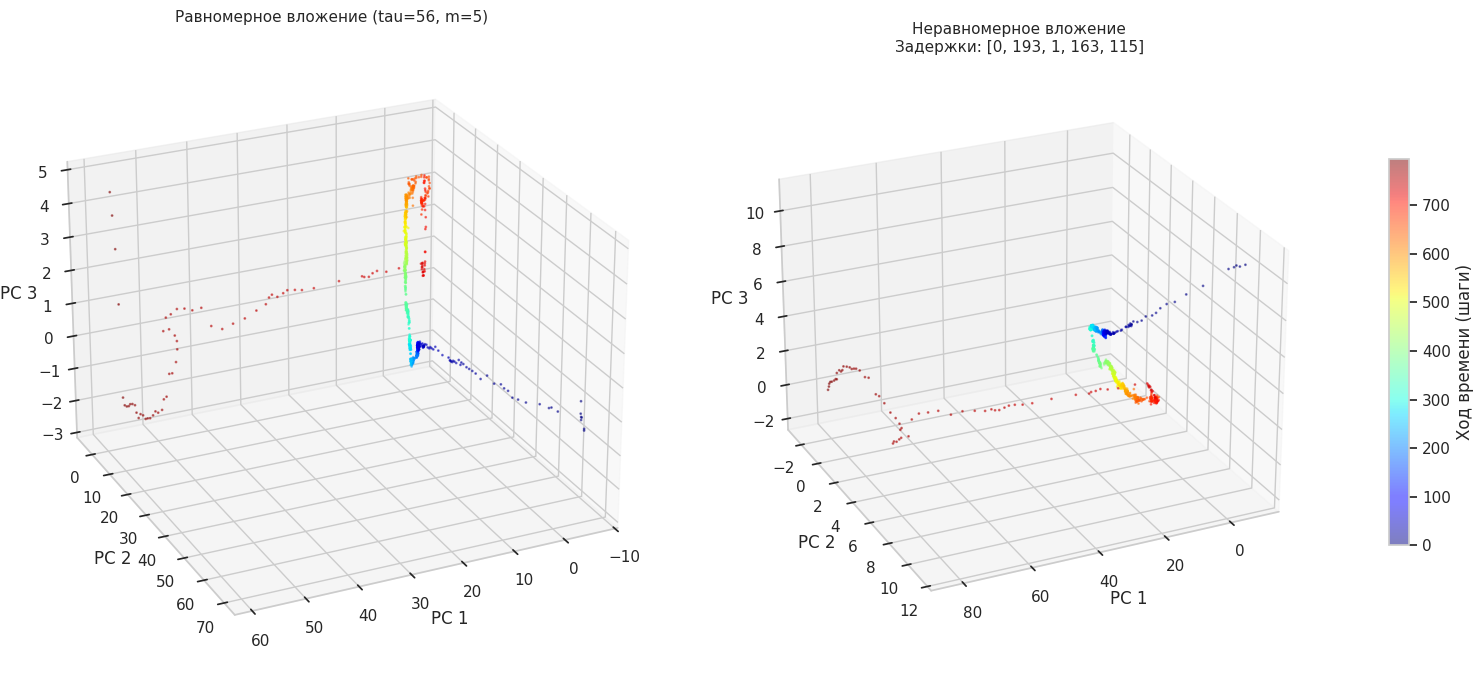

In [25]:
from sklearn.decomposition import PCA

min_len = min(len(X_uniform), len(X_non_uniform))
X_uni_cut = X_uniform[-min_len:]
X_non_cut = X_non_uniform[-min_len:]
time_color = np.arange(min_len)

# PCA для понижения размерности до 3D
pca = PCA(n_components=3)
emb_uni = pca.fit_transform(X_uni_cut)
emb_non = pca.fit_transform(X_non_cut)

fig = plt.figure(figsize=(16, 7))

# Равномерное
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(emb_uni[:, 0], emb_uni[:, 1], emb_uni[:, 2],
                       c=time_color, cmap='jet', s=1, alpha=0.5)
ax1.set_title(f'Равномерное вложение (tau={TAU_OPT}, m={M_OPT})')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.set_zlabel('PC 3')

# Неравномерное
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(emb_non[:, 0], emb_non[:, 1], emb_non[:, 2],
                       c=time_color, cmap='jet', s=1, alpha=0.5)
ax2.set_title(f'Неравномерное вложение\nЗадержки: {non_uniform_taus}')
ax2.set_xlabel('PC 1')
ax2.set_ylabel('PC 2')
ax2.set_zlabel('PC 3')

fig.colorbar(scatter2, ax=ax2, label='Ход времени (шаги)', shrink=0.6, pad=0.1)
ax1.view_init(elev=25, azim=65)
ax2.view_init(elev=25, azim=65)
plt.tight_layout()
plt.show()

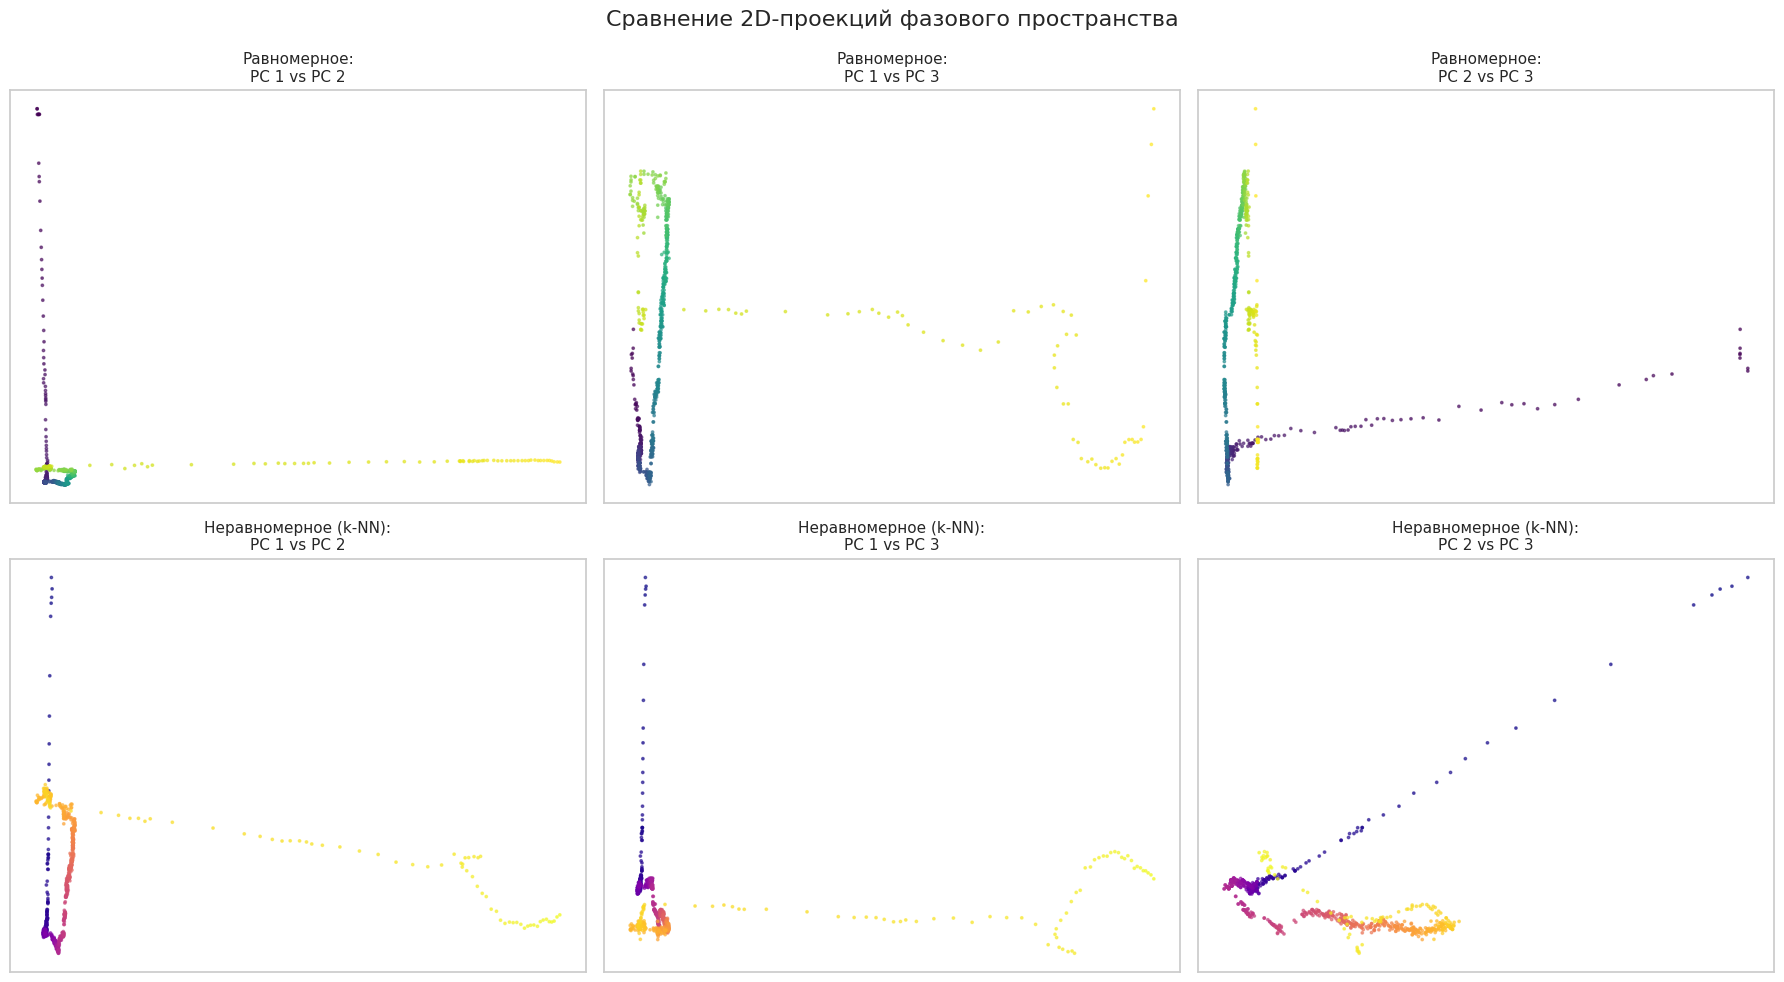

In [26]:
# Создаем сетку графиков 2 строки (Равномерное / Неравномерное) и 3 столбца (Пары компонент)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.suptitle('Сравнение 2D-проекций фазового пространства', fontsize=16)

pairs = [(0, 1), (0, 2), (1, 2)]
pair_names = [('PC 1', 'PC 2'), ('PC 1', 'PC 3'), ('PC 2', 'PC 3')]

for i, (p1, p2) in enumerate(pairs):
    # Равномерное вложение
    axes[0, i].scatter(emb_uni[:, p1], emb_uni[:, p2],
                       c=time_color, cmap='viridis', s=3, alpha=0.6)
    axes[0, i].set_title(f'Равномерное:\n{pair_names[i][0]} vs {pair_names[i][1]}')
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([]) # Убираем цифры осей для чистоты

    # Неравномерное вложение
    axes[1, i].scatter(emb_non[:, p1], emb_non[:, p2],
                       c=time_color, cmap='plasma', s=3, alpha=0.6)
    axes[1, i].set_title(f'Неравномерное (k-NN):\n{pair_names[i][0]} vs {pair_names[i][1]}')
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

#### Анализ результатов вложения и сравнение аттракторов

На основе полученных результатов равномерного и неравномерного вложения можно сделать следующие выводы:

**Результаты равномерного вложения (Uniform Embedding):**
При использовании фиксированной задержки $\tau=56$ и размерности $m=5$ фазовое пространство восстанавливается, однако структура аттрактора (левый график) остается частично "скомканной". Система имеет сложную динамику на разных временных масштабах, которую одна константа $\tau$ не способна полностью раскрыть. Переходные процессы и стационарные состояния визуально пересекаются.

**Результаты неравномерного вложения (Non-uniform Embedding):**
Жадный алгоритм минимизации ошибки предсказания k-NN сформировал вектор задержек: `[0, 193, 1, 163, 115]`.
Физический смысл этого результата крайне логичен: алгоритм автоматически выбрал минимальную задержку ($\tau=1$) для фиксации высокочастотных (мгновенных) изменений системы и набор больших задержек ($\tau \in [115, 193]$) для учета долгосрочной памяти (накопительных процессов и циклов).

**3. Визуальное сравнение (PCA 3D):**
Проекция на 3D-пространство с помощью метода главных компонент (правый график) наглядно доказывает превосходство неравномерного вложения:
* Аттрактор полностью "раскрылся".
* Четко выделилось плотное центральное ядро (вероятно, соответствующее стационарным рабочим режимам оборудования).
* Ярко выражены глобальные петли (1D-циклы в терминологии алгебраической топологии), которые описывают сбросы значений и переходные процессы (остановки/запуски). Траектории не пересекаются хаотично, а образуют строгую геометрическую структуру.

Неравномерное вложение справилось с задачей значительно лучше. Полученное 5-мерное облако точек (размером 827 x 5) обладает выраженной топологической структурой (наличием пустот, петель и кластеров). Именно эту матрицу `X_non_uniform` мы будем использовать на следующем шаге в качестве входных данных для топологического анализа данных (TDA) и вычисления персистентных гомологий.

### Топологический анализ (TDA) и выявление скрытых режимов

#### Построение комплексов Вьеториса-Рипса и диаграмм персистентности

Для анализа динамики во времени применим метод **скользящего окна (Sliding Window)** к полученному на Шаге 3 облаку точек неравномерного вложения `X_non_uniform`. Каждое окно представляет собой локальное подмножество фазовой траектории. К каждому окну применяется алгоритм фильтрации Вьеториса-Рипса: вокруг точек раздуваются сферы радиуса $\epsilon$, и при их пересечении строятся симплициальные комплексы (графы, треугольники, тетраэдры).

Мы будем отслеживать топологические особенности двух типов:
* $H_0$ — компоненты связности (кластеры точек).
* $H_1$ — одномерные циклы (петли, «дырки от бублика», отражающие периодическую или квазипериодическую динамику системы).


Примените метод персистентных гомологий (постройте симплициальные комплексы) к полученным на шаге 3 облакам точек.


In [27]:
pip install giotto-tda

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, PersistenceImage, BettiCurve
from gtda.plotting import plot_diagram
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Метод скользящего окна (Sliding Window)
WINDOW_SIZE = 80
STRIDE = 10

point_clouds = []
time_indices = []

for i in range(0, len(X_non_uniform) - WINDOW_SIZE + 1, STRIDE):
    window_pc = X_non_uniform[i : i + WINDOW_SIZE]
    point_clouds.append(window_pc)
    time_indices.append(i + WINDOW_SIZE // 2)

point_clouds = np.array(point_clouds)
print(f"Сформировано локальных облаков точек (окон): {point_clouds.shape}")

# Вычисление персистентных гомологий для H0 и H1
vr = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagrams = vr.fit_transform(point_clouds)
print(f"Размерность тензора диаграмм персистентности: {diagrams.shape}")

# Диаграмма персистентности для окна №10
plot_diagram(diagrams[10])

Сформировано локальных облаков точек (окон): (75, 80, 5)
Размерность тензора диаграмм персистентности: (75, 92, 3)


In [36]:
plot_diagram(diagrams[1])

#### Векторизация диаграмм персистентности

Диаграммы персистентности представляют собой мультимножества точек пар (birth, death) разного размера. Стандартные алгоритмы машинного обучения и кластеризации не могут работать с ними напрямую. Для этого применяется векторизация — отображение диаграмм в функциональные пространства фиксированной размерности.

Согласно заданию, мы вычисляем 4 различных топологических признака:
1.  **Ландшафты персистентности (Persistence Landscapes):** Набор непрерывных кусочно-линейных функций, кодирующих персистентность точек. Метод устойчив к шуму и сохраняет сильные статистические свойства.
2.  **Образы персистентности (Persistence Images):** Дискретизация диаграммы путем сглаживания точек двумерным Гауссовым ядром с последующим переходом к пиксельной матрице (поверхности плотности).
3.  **Кривые Бетти (Betti Curves):** Функции, показывающие количество живых топологических пространств ($H_0$ и $H_1$) при каждом фиксированном значении радиуса фильтрации $\epsilon$.
4.  **Кривые Эйлера (Euler Characteristic Curves):** Интегральная характеристика, рассчитываемая как знакопеременная сумма чисел Бетти: $\chi(\epsilon) = \beta_0(\epsilon) - \beta_1(\epsilon)$. Отражает общую топологическую структуру комплекса на каждом шаге фильтрации.

In [48]:
# Задаем единую сетку разрешения для функциональных векторов
N_BINS = 100

# Инициализируем трансформеры из giotto-tda
landscape = PersistenceLandscape(n_layers=3, n_bins=N_BINS)
persistence_image = PersistenceImage(n_bins=20) # Матрица 20x20
betti_curve = BettiCurve(n_bins=N_BINS)

# Вычисляем Ландшафты и Образы
features_landscape = landscape.fit_transform(diagrams).reshape(len(diagrams), -1)
features_image     = persistence_image.fit_transform(diagrams).reshape(len(diagrams), -1)

# Вычисляем Кривые Бетти (возвращает тензор: [кол-во окон, размерность гомологии, n_bins])
betti_raw = betti_curve.fit_transform(diagrams)
features_betti = betti_raw.reshape(len(diagrams), -1)

# Вычисляем Кривые Эйлера аналитически: X(e) = H0(e) - H1(e)
# Индекс 0 соответствует H0, индекс 1 соответствует H1
features_euler = (betti_raw[:, 0, :] - betti_raw[:, 1, :]).reshape(len(diagrams), -1)

print("Размерности полученных пространств признаков:")
print(f"Ландшафты: {features_landscape.shape}")
print(f"Образы:    {features_image.shape}")
print(f"Кривые Бетти: {features_betti.shape}")
print(f"Кривые Эйлера: {features_euler.shape}")

# Объединяем все топологические признаки в единую матрицу
X_tda_combined = np.hstack([features_landscape, features_image, features_betti, features_euler])
print(f"\nИтоговая размерность объединенного топологического пространства: {X_tda_combined.shape}")

Размерности полученных пространств признаков:
Ландшафты: (75, 600)
Образы:    (75, 800)
Кривые Бетти: (75, 200)
Кривые Эйлера: (75, 100)

Итоговая размерность объединенного топологического пространства: (75, 1700)


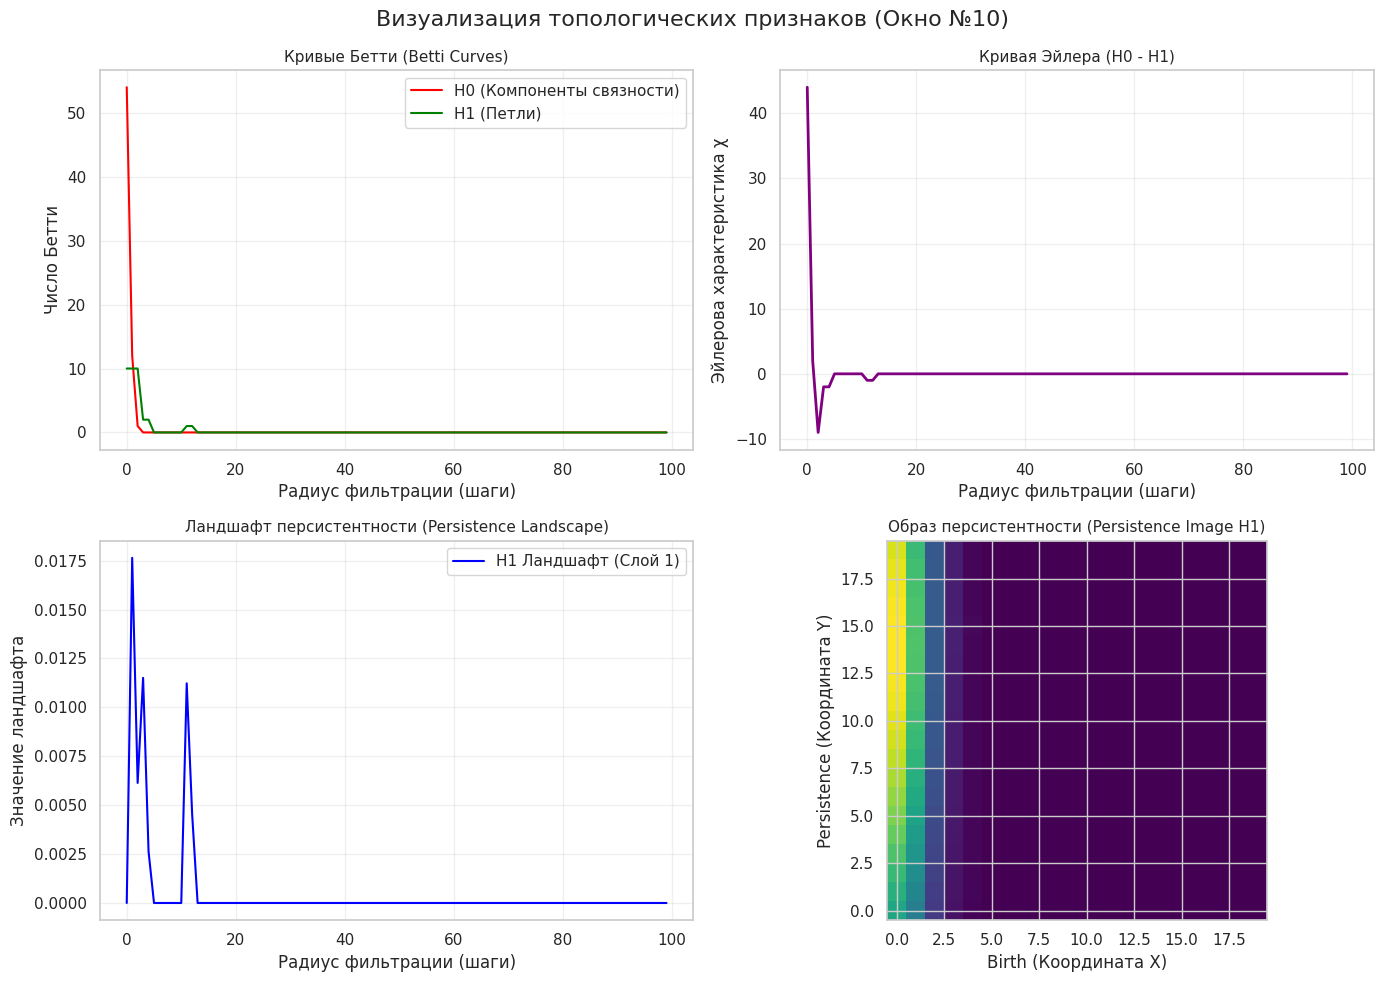

In [50]:
import matplotlib.pyplot as plt

# Выберем окно для демонстрации
sample_idx = 10

L_raw = landscape.fit_transform(diagrams)          # Ландшафты
I_raw = persistence_image.fit_transform(diagrams)  # Образы
B_raw = betti_curve.fit_transform(diagrams)        # Кривые Бетти
E_raw = B_raw[:, 0, :] - B_raw[:, 1, :]            # Кривая Эйлера

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle(f'Визуализация топологических признаков (Окно №{sample_idx})', fontsize=16)

# Кривые Бетти (Betti Curves)
axes[0, 0].plot(B_raw[sample_idx, 0, :], label='H0 (Компоненты связности)', color='red')
axes[0, 0].plot(B_raw[sample_idx, 1, :], label='H1 (Петли)', color='green')
axes[0, 0].set_title('Кривые Бетти (Betti Curves)')
axes[0, 0].set_xlabel('Радиус фильтрации (шаги)')
axes[0, 0].set_ylabel('Число Бетти')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Кривая Эйлера (Euler Characteristic)
axes[0, 1].plot(E_raw[sample_idx, :], color='purple', linewidth=2)
axes[0, 1].set_title('Кривая Эйлера (H0 - H1)')
axes[0, 1].set_xlabel('Радиус фильтрации (шаги)')
axes[0, 1].set_ylabel('Эйлерова характеристика χ')
axes[0, 1].grid(True, alpha=0.3)

# Ландшафты персистентности (Persistence Landscapes)
# Рисуем первый слой ландшафта для H1 (самый информативный для циклов)
# В giotto-tda размерность обычно (n_samples, n_homology_dims * n_layers, n_bins)
# H1 начинается со второй половины слоев
h1_start_idx = L_raw.shape[1] // 2
axes[1, 0].plot(L_raw[sample_idx, h1_start_idx, :], label='H1 Ландшафт (Слой 1)', color='blue')
axes[1, 0].set_title('Ландшафт персистентности (Persistence Landscape)')
axes[1, 0].set_xlabel('Радиус фильтрации (шаги)')
axes[1, 0].set_ylabel('Значение ландшафта')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Образ персистентности (Persistence Image)
# Отрисуем матрицу плотности для H1
axes[1, 1].imshow(I_raw[sample_idx, 1, :, :], origin='lower', cmap='viridis')
axes[1, 1].set_title('Образ персистентности (Persistence Image H1)')
axes[1, 1].set_xlabel('Birth (Координата X)')
axes[1, 1].set_ylabel('Persistence (Координата Y)')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

**Интерпретация векторизаций:**
Как видно на графиках, мультимножество точек диаграммы персистентности успешно преобразовано в векторы фиксированной длины:
* **Кривые Бетти и Эйлера** показывают динамику изменения топологии при "раздувании" сфер (рост и смерть дыр).
* **Ландшафты** выделяют наиболее устойчивые (долгоживущие) топологические фичи в виде пиков.
* **Образ персистентности** представляет собой тепловую карту (пиксельную матрицу 20x20), где яркие зоны соответствуют скоплению долгоживущих точек H1.
Именно эти числовые векторы подаются на вход алгоритму кластеризации K-Means для выявления скрытых режимов.

#### Применение алгоритмов кластеризации и интерпретация режимов

Используя объединенный вектор топологических характеристик `X_tda_combined`, мы обучим алгоритм кластеризации **K-Means**. Топологические признаки избавлены от амплитудных флуктуаций самого числового ряда, поэтому кластеры будут отражать именно геометрические свойства траектории (например: "компактный плотный клубок" $\rightarrow$ стабильная работа, "широкое кольцо" $\rightarrow$ выраженный циклический процесс нагрева/охлаждения, "хаотический выброс" $\rightarrow$ остановка системы).

Мы выберем $K = 3$ кластера, что согласуется с технологической природой промышленных агрегатов (стационарная работа, переходный процесс/смена нагрузки, аварийный или плановый останов).

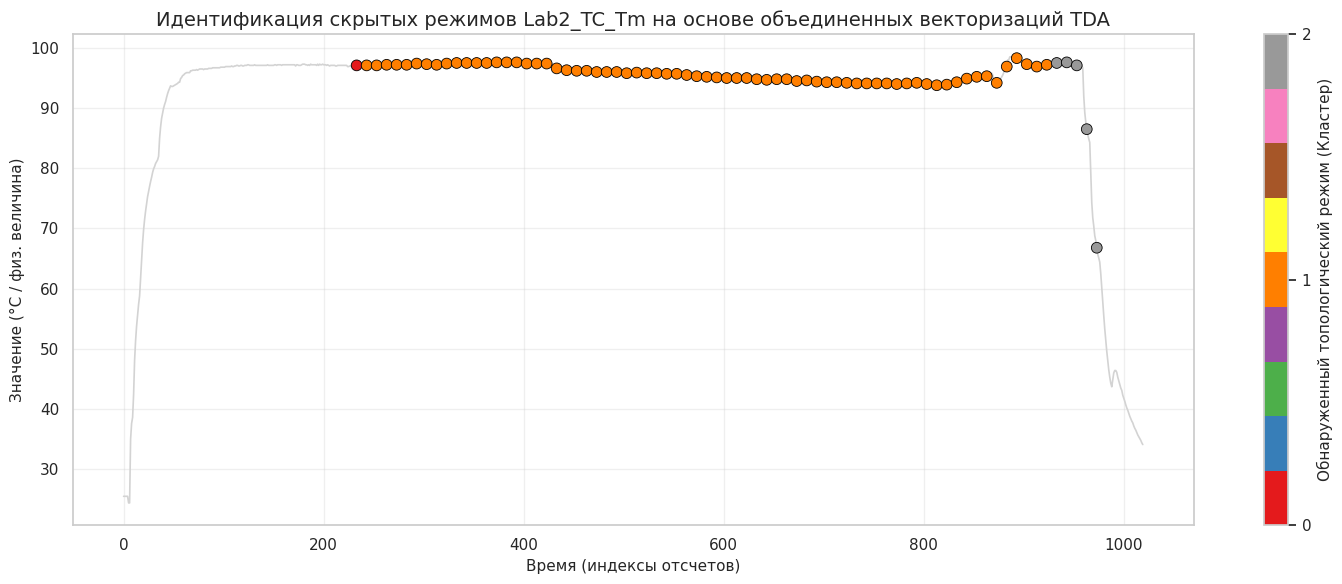

In [49]:
# Масштабирование признаков перед кластеризацией
scaler = StandardScaler()
X_tda_scaled = scaler.fit_transform(X_tda_combined)

# Кластеризация методом K-Means
N_CLUSTERS = 3
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)
cluster_labels = kmeans.fit_predict(X_tda_scaled)

# Синхронизация временных шкал
# Нам нужно учесть максимальный сдвиг, внесенный неравномерным вложением на Шаге 3
max_tau = max(non_uniform_taus)
real_time_indices = [idx + max_tau for idx in time_indices]

# Визуализация результатов: сопоставление кластеров с исходным временным рядом
plt.figure(figsize=(15, 6))

# Отрисовка фонового непрерывного ряда
plt.plot(np.arange(len(y_arr)), y_arr, color='lightgray', linewidth=1.2, label="Временной ряд (Target)", zorder=1)

# Наложение топологических режимов (точки окон)
scatter = plt.scatter(real_time_indices, y_arr[real_time_indices],
                      c=cluster_labels, cmap='Set1', s=60, zorder=2, edgecolors='black', linewidths=0.6)

plt.title(f'Идентификация скрытых режимов {TARGET_COL} на основе объединенных векторизаций TDA', fontsize=14)
plt.xlabel('Время (индексы отсчетов)', fontsize=11)
plt.ylabel('Значение (°C / физ. величина)', fontsize=11)

# Настройка легенды для кластеров
cbar = plt.colorbar(scatter, ticks=range(N_CLUSTERS))
cbar.set_label('Обнаруженный топологический режим (Кластер)', fontsize=11)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Примените алгоритмы кластеризации к полученным топологическим признакам.



Интерпретация: Сопоставьте найденные кластеры с исходным временным рядом (раскрасьте график временного ряда цветами кластеров). Объясните, какие режимы смогла найти топология.